> **Update:** the DNN-G baseline in Section 4/5 below was underperforming Bayesian (badly, on ATT) and even NLS (on CBF) — the opposite of Ishida et al. 2024's own findings for supervised DNN vs. conventional fitting. Section 4 now uses their paper-matched architecture (9x50 CBF / 9x100 ATT) and MAE loss instead of the previous 5x128/4x64 MSE config. **Priority is getting DNN-G to legitimately beat Bayesian/NLS before revisiting ELM** — the ELM/hybrid sections (6 onward) are left in place structurally but are not the current focus; skip re-running them until the base DNN is fixed if you want faster iteration.

---

# Experiment H — DNN + ELM Hybrid for ASL CBF/ATT Estimation

**Scientific objective.** Determine whether an Extreme Learning Machine (ELM), used either
standalone or in combination with the best existing DNN (**Experiment G**), can improve
CBF and ATT estimation from noisy multi-PLD ASL signals enough to outperform the
Bayesian and NLS reference methods.

This is a **new, self-contained notebook**. It does not reproduce Experiments A–F as
separate training runs. It only carries forward what Experiment G actually needs:
the validated physics simulator, the validated normalization/standardization
procedure, and the Experiment-G DNN architecture (which is retrained here because
its weights were not saved in the source notebook — see Section 5).

**Primary question:**
> Can ELM provide complementary information that improves the already-strong
> Experiment-G DNN, and can the resulting hybrid beat Bayesian / NLS?

## SECTION 1 — Environment and reproducibility

In [2]:
import os, copy, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.optimize import least_squares
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# QUICK_TEST=True runs the whole pipeline end-to-end on tiny sample
# sizes / small seed counts / coarse grids so you can smoke-test the
# notebook logic in a couple of minutes on CPU.
#
# Set QUICK_TEST=False (and run on a GPU, e.g. Kaggle) to reproduce
# the full-scale Experiment H results at the sample sizes specified
# in the experiment design (N_TRAIN=1,000,000 / N_VAL=100,000).
# ------------------------------------------------------------------
QUICK_TEST = False

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"QUICK_TEST mode: {QUICK_TEST}")

OUTPUT_DIR = "/kaggle/working/experiment_H_DNN_ELM" if os.path.isdir("/kaggle/working") else "./experiment_H_DNN_ELM"
os.makedirs(OUTPUT_DIR, exist_ok=True)
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Device: cuda
QUICK_TEST mode: False
Output directory: /kaggle/working/experiment_H_DNN_ELM


## SECTION 2 — Physics simulator (validated, unchanged)

Reused verbatim from the Experiment F/G notebook. Constants, forward model, PLDs,
`SCALE`, and noise mechanism are not modified. The zero-noise training input is
`2 x physical_signal` (sum of two Rician-magnitude repeats, `mc + ml`), exactly as
validated previously.

In [3]:
# ---- Physics constants — UNCHANGED ----
PLDs  = np.array([1.525, 2.025, 2.525, 3.025])   # seconds
tau   = 1.8
T1t   = 1.2
T1a   = 1.66
alpha = 0.85
beta  = 0.75
lmbda = 0.9
SCALE = 100_000.0

CBF_MIN, CBF_MAX = 0.0,  100.0
ATT_MIN, ATT_MAX = 0.5,    3.0

REF_CBF, REF_ATT, REF_PLD, REF_LD = 50.0, 1.6, 2.0, 1.8   # UNCHANGED reference case

def asl_signal(pld, ld, f_per_s, delta):
    prefix = 2.0 * alpha * beta * T1t * (1.0 / lmbda) * f_per_s
    e_att  = np.exp(-delta / T1a)
    t1     = np.exp(-max(pld - delta,       0.0) / T1t)
    t2     = np.exp(-max(ld  + pld - delta, 0.0) / T1t)
    return prefix * e_att * (t1 - t2)

def compute_signals(plds, ld, f_per_s, delta):
    return np.array([asl_signal(w, ld, f_per_s, delta) for w in plds])

def compute_signals_vec(cbf, att, ld=tau):
    """Vectorized version of the SAME formula, for fast batch generation.
    cbf, att: shape (N,). Returns shape (N, len(PLDs))."""
    f_per_s = (cbf / (6000.0 * lmbda))[:, None]
    delta   = att[:, None]
    pld     = PLDs[None, :]
    prefix  = 2.0 * alpha * beta * T1t * (1.0 / lmbda) * f_per_s
    e_att   = np.exp(-delta / T1a)
    t1      = np.exp(-np.maximum(pld - delta,      0.0) / T1t)
    t2      = np.exp(-np.maximum(ld  + pld - delta, 0.0) / T1t)
    return prefix * e_att * (t1 - t2)

_f_ref     = REF_CBF / (6000.0 * lmbda)
SIG_REF_SC = abs(asl_signal(REF_PLD, REF_LD, _f_ref, REF_ATT)) * SCALE
print(f"Reference signal (scaled): {SIG_REF_SC:.4f}   (validated value: ~334.2039)")

# Sanity check against the validated reference case
_chk_f = 50.0 / (6000.0 * lmbda)
_chk = compute_signals(PLDs, tau, _chk_f, 1.5) * SCALE
print("Sanity check CBF=50, ATT=1.5 physical signal:", np.round(_chk, 5))
print("  (validated: [485.16653 319.84150 210.85252 139.00255])")
print("Sanity check zero-noise training input (2x):  ", np.round(2.0 * _chk, 5))
print("  (validated: [970.33307 639.68300 421.70505 278.00510])")

assert np.allclose(_chk, [485.16653, 319.8415, 210.85252, 139.00255], atol=1e-2), \
    "Physics simulator does not match validated reference signal!"
print("\n[OK] Physics simulator matches validated reference values.")

Reference signal (scaled): 334.2039   (validated value: ~334.2039)
Sanity check CBF=50, ATT=1.5 physical signal: [485.16655 319.8415  210.85251 139.00254]
  (validated: [485.16653 319.84150 210.85252 139.00255])
Sanity check zero-noise training input (2x):   [970.3331  639.68301 421.70503 278.00509]
  (validated: [970.33307 639.68300 421.70505 278.00510])

[OK] Physics simulator matches validated reference values.


## SECTION 3 — Training-data generation

Same SNR sampling distribution and same `mc + ml` Rician noise mechanism as
Experiment F/G. We additionally draw an **independent held-out test set**
(the source notebook only had train/val — Experiment H needs a genuine test
split so that ELM seed selection, ensemble alpha selection, and DNN vs. hybrid
comparisons are never tuned on the data they are evaluated on).

In [4]:
SNR_VALUES = [5, 8, 10, 12, 15, 20, 30, 50, 100, 200, 500, np.inf]
# Use perfectly balanced uniform probabilities (approx 8.33% each)
SNR_PROBS  = [1.0 / len(SNR_VALUES)] * len(SNR_VALUES)

assert abs(sum(SNR_PROBS) - 1.0) < 1e-9
assert len(SNR_VALUES) == len(SNR_PROBS)

def generate_data(N_total, rng, snr_values=SNR_VALUES, snr_probs=SNR_PROBS):
    """Unchanged from Experiment F/G: uniform CBF/ATT ground truth, SNR sampled
    from SNR_PROBS, Rician mc/ml noise mechanism, X = mc + ml."""
    cbf_gt = rng.uniform(CBF_MIN, CBF_MAX, N_total).astype(np.float64)
    att_gt = rng.uniform(ATT_MIN, ATT_MAX, N_total).astype(np.float64)

    snr_choice_idx = rng.choice(len(snr_values), size=N_total, p=snr_probs)
    snr_arr = np.array(snr_values, dtype=np.float64)[snr_choice_idx]

    sig = compute_signals_vec(cbf_gt, att_gt) * SCALE

    with np.errstate(divide='ignore'):
        sd = SIG_REF_SC / snr_arr
    sd = sd[:, None]

    e1 = rng.normal(0.0, 1.0, size=sig.shape) * sd
    e2 = rng.normal(0.0, 1.0, size=sig.shape) * sd
    e3 = rng.normal(0.0, 1.0, size=sig.shape) * sd
    e4 = rng.normal(0.0, 1.0, size=sig.shape) * sd

    mc = np.sqrt((sig + e1) ** 2 + e2 ** 2)
    ml = np.sqrt((sig + e3) ** 2 + e4 ** 2)
    X = (mc + ml).astype(np.float32)

    Y = np.stack([cbf_gt, att_gt], axis=1).astype(np.float32)
    return X, Y, snr_arr

if QUICK_TEST:
    N_TRAIN, N_VAL, N_TEST = 20_000, 4_000, 4_000
else:
    N_TRAIN, N_VAL, N_TEST = 1_000_000, 100_000, 100_000

rng_tr   = np.random.default_rng(42)
rng_val  = np.random.default_rng(99)
rng_test = np.random.default_rng(7)   # independent from train/val, held out for everything

X_tr,   Y_tr,   snr_tr   = generate_data(N_TRAIN, rng_tr)
X_val,  Y_val,  snr_val  = generate_data(N_VAL,   rng_val)
X_test, Y_test, snr_test = generate_data(N_TEST,  rng_test)

print(f"Train {X_tr.shape} | Val {X_val.shape} | Test {X_test.shape}")
print("Test set is used ONLY for final reporting: never for normalization fitting,")
print("ELM training, ELM seed selection, or ensemble alpha selection.")

Train (1000000, 4) | Val (100000, 4) | Test (100000, 4)
Test set is used ONLY for final reporting: never for normalization fitting,
ELM training, ELM seed selection, or ensemble alpha selection.


In [5]:
# ---- Input normalization: fit on TRAIN only ----
X_mean = X_tr.mean(axis=0, keepdims=True).astype(np.float32)
X_std  = X_tr.std(axis=0,  keepdims=True).astype(np.float32) + 1e-8

X_tr_n   = (X_tr   - X_mean) / X_std
X_val_n  = (X_val  - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

print("X_mean:", X_mean.squeeze())
print("X_std :", X_std.squeeze())
assert np.all(X_std > 0), "X_std must be > 0 for every feature"
print("[OK] X_std > 0 for every feature.")

# ---- Target standardization: fit on TRAIN only ----
CBF_mean, CBF_std = float(Y_tr[:, 0].mean()), float(Y_tr[:, 0].std() + 1e-8)
ATT_mean, ATT_std = float(Y_tr[:, 1].mean()), float(Y_tr[:, 1].std() + 1e-8)

print(f"\nCBF target: mean={CBF_mean:.3f} std={CBF_std:.3f}  (physical range [{CBF_MIN},{CBF_MAX}])")
print(f"ATT target: mean={ATT_mean:.3f} std={ATT_std:.3f}  (physical range [{ATT_MIN},{ATT_MAX}])")

np.save(os.path.join(OUTPUT_DIR, "X_mean.npy"), X_mean)
np.save(os.path.join(OUTPUT_DIR, "X_std.npy"),  X_std)
np.save(os.path.join(OUTPUT_DIR, "CBF_y_mean_std.npy"), np.array([CBF_mean, CBF_std], dtype=np.float32))
np.save(os.path.join(OUTPUT_DIR, "ATT_y_mean_std.npy"), np.array([ATT_mean, ATT_std], dtype=np.float32))

# ---- Clean (noise-free) evaluation population — same grid as Experiment G ----
CBF_VALUES_CLEAN = np.linspace(10.0, 100.0, 46)
ATT_VALUES_CLEAN = np.linspace(0.5, 3.0, 52)
cbf_grid, att_grid = np.meshgrid(CBF_VALUES_CLEAN, ATT_VALUES_CLEAN, indexing="ij")
clean_cbf_true = cbf_grid.reshape(-1)
clean_att_true = att_grid.reshape(-1)

clean_sig = compute_signals_vec(clean_cbf_true, clean_att_true) * SCALE
clean_input_phys = 2.0 * clean_sig
clean_input_norm = (clean_input_phys - X_mean) / X_std
print(f"\nClean population grid: {len(clean_cbf_true)} points "
      f"({len(CBF_VALUES_CLEAN)} CBF x {len(ATT_VALUES_CLEAN)} ATT)")

X_mean: [656.97815 561.0035  435.7017  308.12283]
X_std : [480.33676 344.74948 252.7479  178.76736]
[OK] X_std > 0 for every feature.

CBF target: mean=50.003 std=28.864  (physical range [0.0,100.0])
ATT target: mean=1.750 std=0.721  (physical range [0.5,3.0])

Clean population grid: 2392 points (46 CBF x 52 ATT)


## SECTION 4 — DNN architecture: paper-matched configuration (fixes Experiment G)

**Why this changed.** The Experiment-G baseline (CBF: 5 hidden layers x 128 neurons, ATT: 4 hidden layers x 64 neurons, MSE loss) was underperforming both the Bayesian and NLS reference methods, especially on ATT (RMSE ~0.30 vs Bayesian's ~0.08 at SNR=10) and, unexpectedly, losing to plain NLS on CBF too (RMSE ~4.27 vs ~2.98 at SNR=10) — the opposite of what Ishida et al. 2024 report for their supervised DNN vs. their conventional (WD+LS) method.

Two concrete deviations from Ishida et al.'s own grid-search-validated hyperparameters (their Table 1) stood out:

1. **Loss function.** Their 96-configuration grid search found **MAE** beat MSE for both supervised CBF and supervised ATT networks. This notebook was using `nn.MSELoss()`. MSE over-weights the large-error tail that Rician noise produces, which is exactly the kind of bias a Bayesian method with informative priors (or a direct least-squares fit) doesn't suffer from — a plausible explanation for the CBF gap vs. NLS.
2. **Capacity, especially for ATT.** Their optimal supervised architecture was **9 hidden layers** for both networks — 50 neurons/layer for CBF, 100 neurons/layer for ATT. This notebook's ATT net (4 layers x 64 neurons) had roughly a third of the depth and two-thirds of the width of the paper's ATT net. ATT is the harder target (it defines the *shape*/timing of the kinetic curve, not just a scale factor), so under-capacity there is the more likely driver of the large ATT gap vs. Bayesian.

**Fix applied below:** CBFnet -> 9x50, ATTnet -> 9x100 (matching Table 1 of Ishida et al. 2024 exactly), loss -> MAE (`nn.L1Loss()`) for both. Old cached weights are not reused (new save paths below), so this forces a genuine retrain under the new configuration. Patience is also raised slightly (10 -> 15) since deeper nets take a few more epochs to shake out noise in the validation curve before it's safe to call convergence.

In [ ]:
class StandardizedNet(nn.Module):
    """Unchanged from Experiment F/G. ELU MLP backbone, kaiming-normal init,
    predicts a standardized target and rescales+clamps to physical units."""
    def __init__(self, input_dim, n_hidden_layers, n_neurons, y_mean, y_std, y_min, y_max):
        super().__init__()
        self.y_mean = y_mean
        self.y_std  = y_std
        self.y_min  = y_min
        self.y_max  = y_max
        layers = [nn.Linear(input_dim, n_neurons), nn.ELU()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(n_neurons, n_neurons), nn.ELU()]
        layers.append(nn.Linear(n_neurons, 1))
        self.backbone = nn.Sequential(*layers)
        for m in self.backbone.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.backbone(x)

    def predict_physical(self, x):
        with torch.no_grad():
            std_pred = self.forward(x).squeeze(-1)
        phys_pred = std_pred * self.y_std + self.y_mean
        return phys_pred.clamp(self.y_min, self.y_max)

    def penultimate_features(self, x):
        """Feature extraction hook for Section 11 (DNN-feature -> ELM).
        Returns the activation of the last hidden ELU layer, before the
        final linear output layer."""
        with torch.no_grad():
            h = x
            for layer in list(self.backbone.children())[:-1]:   # everything except final Linear
                h = layer(h)
        return h


INPUT_DIM = len(PLDs)

# Paper-matched CBF network: 9 hidden layers x 50 neurons (Ishida et al. 2024, Table 1)
CBFnet_G = StandardizedNet(INPUT_DIM, n_hidden_layers=9, n_neurons=50,
                            y_mean=CBF_mean, y_std=CBF_std, y_min=CBF_MIN, y_max=CBF_MAX).to(device)

# Paper-matched ATT network: 9 hidden layers x 100 neurons (Ishida et al. 2024, Table 1)
ATTnet_G = StandardizedNet(INPUT_DIM, n_hidden_layers=9, n_neurons=100,
                            y_mean=ATT_mean, y_std=ATT_std, y_min=ATT_MIN, y_max=ATT_MAX).to(device)

n_params_cbf = sum(p.numel() for p in CBFnet_G.parameters())
n_params_att = sum(p.numel() for p in ATTnet_G.parameters())
print(f"CBFnet_G (paper-matched, 9x50)  params: {n_params_cbf}")
print(f"ATTnet_G (paper-matched, 9x100) params: {n_params_att}")

## SECTION 5 — DNN training / loading

The Experiment-G weights were **not saved** in the source notebook, so this
section retrains Experiment G from scratch using the exact same training loop,
optimizer, and early-stopping rule as before (Adam, lr=1e-3, batch size 512,
patience 10, MSE loss on the standardized target, gradient clipping at 1.0). If
`CBF_G_best.pth` / `ATT_G_best.pth` already exist on disk (e.g. from a previous
run of this notebook), they are loaded instead of retraining.

In [ ]:
def train_standardized(net, X_tr_n, Y_col_tr, X_val_n, Y_col_val,
                        batch_size=512, max_epochs=200, patience=10, lr=1e-3, verbose=True):
    Y_tr_std  = (Y_col_tr - net.y_mean) / net.y_std
    Y_val_std = (Y_col_val - net.y_mean) / net.y_std

    ds_tr  = TensorDataset(torch.tensor(X_tr_n, dtype=torch.float32),
                            torch.tensor(Y_tr_std, dtype=torch.float32).unsqueeze(1))
    ds_val = TensorDataset(torch.tensor(X_val_n, dtype=torch.float32),
                            torch.tensor(Y_val_std, dtype=torch.float32).unsqueeze(1))

    ld_tr  = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    ld_val = DataLoader(ds_val, batch_size=batch_size)

    optim = torch.optim.Adam(net.parameters(), lr=lr)
    crit  = nn.L1Loss()   # MAE — matches Ishida et al. 2024 Table 1 for supervised nets

    best_val   = float("inf")
    best_state = copy.deepcopy(net.state_dict())
    no_imp = 0

    for epoch in range(max_epochs):
        net.train()
        tr = 0.0
        for xb, yb in ld_tr:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad()
            pred = net(xb)
            loss = crit(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optim.step()
            tr += loss.item()
        tr /= len(ld_tr)

        net.eval()
        with torch.no_grad():
            vl = 0.0
            for xb, yb in ld_val:
                xb, yb = xb.to(device), yb.to(device)
                pred = net(xb)
                vl += crit(pred, yb).item()
            vl /= len(ld_val)

        if verbose and (epoch % 5 == 0 or epoch == max_epochs - 1):
            print(f"  Epoch {epoch+1:3d}: train={tr:.6f} val={vl:.6f}")

        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(net.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"  Early stopping at epoch {epoch+1} (no val improvement for {patience} epochs)")
                break

    net.load_state_dict(best_state)
    return net

# New paths: paper-matched config (9x50 CBF / 9x100 ATT, MAE loss) — must NOT collide with
# old 5x128/4x64-MSE weights, since those have incompatible shapes and different training.
CBF_G_PATH = os.path.join(OUTPUT_DIR, "CBF_papermatched_9x50_MAE_best.pth")
ATT_G_PATH = os.path.join(OUTPUT_DIR, "ATT_papermatched_9x100_MAE_best.pth")
MAX_EPOCHS = 20 if QUICK_TEST else 200

if os.path.exists(CBF_G_PATH) and os.path.exists(ATT_G_PATH):
    print("Loading existing Experiment-G weights ...")
    CBFnet_G.load_state_dict(torch.load(CBF_G_PATH, map_location=device))
    ATTnet_G.load_state_dict(torch.load(ATT_G_PATH, map_location=device))
else:
    print("No saved paper-matched weights found — training from scratch.\n")
    print("Training ATTnet (paper-matched: 9 layers x 100 neurons, MAE loss)...")
    ATTnet_G = train_standardized(ATTnet_G, X_tr_n, Y_tr[:, 1], X_val_n, Y_val[:, 1],
                                   lr=1e-3, max_epochs=MAX_EPOCHS, patience=15)
    print("\nTraining CBFnet_G (paper-matched: 9 layers x 50 neurons, MAE loss)...")
    CBFnet_G = train_standardized(CBFnet_G, X_tr_n, Y_tr[:, 0], X_val_n, Y_val[:, 0],
                                   lr=1e-3, max_epochs=MAX_EPOCHS, patience=15)
    torch.save(CBFnet_G.state_dict(), CBF_G_PATH)
    torch.save(ATTnet_G.state_dict(), ATT_G_PATH)
    print(f"\nSaved paper-matched weights to {CBF_G_PATH} and {ATT_G_PATH}")

CBFnet_G.eval(); ATTnet_G.eval()

print("\n" + "=" * 70)
print("PAPER-MATCHED DNN — CONFIGURATION SUMMARY")
print("=" * 70)
print(f"CBFnet architecture : 9 hidden layers x 50 neurons,  ELU, {n_params_cbf} params")
print(f"ATTnet architecture : 9 hidden layers x 100 neurons, ELU, {n_params_att} params")
print(f"Training samples    : N_train={N_TRAIN}, N_val={N_VAL}, N_test={N_TEST}")
print(f"Optimizer           : Adam, lr=1e-3, batch_size=512, grad_clip=1.0")
print(f"Loss function       : MAE (L1Loss) — matches Ishida et al. 2024 Table 1")
print(f"Early stopping      : patience=15 epochs on val MAE (standardized target)")
print(f"X_mean              : {X_mean.squeeze()}")
print(f"X_std               : {X_std.squeeze()}")
print(f"CBF target mean/std : {CBF_mean:.4f} / {CBF_std:.4f}")
print(f"ATT target mean/std : {ATT_mean:.4f} / {ATT_std:.4f}")

## Metric helpers (used throughout)

In [8]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    error = y_pred - y_true
    mse  = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(error))
    bias = np.mean(error)
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    mean_t, mean_p = np.mean(y_true), np.mean(y_pred)
    var_t,  var_p  = np.var(y_true),  np.var(y_pred)
    cov = np.mean((y_true - mean_t) * (y_pred - mean_p))
    denom = var_t + var_p + (mean_t - mean_p) ** 2
    ccc = (2.0 * cov / denom) if denom > 0 else np.nan
    return {"RMSE": rmse, "MSE": mse, "MAE": mae, "Bias": bias, "R2": r2, "CCC": ccc}

def dnn_predict_physical(net, X_norm):
    x_t = torch.tensor(X_norm.astype(np.float32), dtype=torch.float32, device=device)
    return net.predict_physical(x_t).cpu().numpy().reshape(-1)

# Experiment-G DNN predictions, reused everywhere below
CBF_DNN_tr   = dnn_predict_physical(CBFnet_G, X_tr_n)
ATT_DNN_tr   = dnn_predict_physical(ATTnet_G, X_tr_n)
CBF_DNN_val  = dnn_predict_physical(CBFnet_G, X_val_n)
ATT_DNN_val  = dnn_predict_physical(ATTnet_G, X_val_n)
CBF_DNN_test = dnn_predict_physical(CBFnet_G, X_test_n)
ATT_DNN_test = dnn_predict_physical(ATTnet_G, X_test_n)

print("DNN-G clean-data-independent sanity check (test split):")
print("  CBF:", calc_metrics(Y_test[:, 0], CBF_DNN_test))
print("  ATT:", calc_metrics(Y_test[:, 1], ATT_DNN_test))

DNN-G clean-data-independent sanity check (test split):
  CBF: {'RMSE': np.float64(3.7057638384395086), 'MSE': np.float64(13.73268562628592), 'MAE': np.float64(2.4699605799114077), 'Bias': np.float64(0.14743687357538612), 'R2': np.float64(0.9835083019955518), 'CCC': np.float64(0.9916976157549044)}
  ATT: {'RMSE': np.float64(0.30529877151885837), 'MSE': np.float64(0.09320733989092407), 'MAE': np.float64(0.19071779679238796), 'Bias': np.float64(0.005699982923865319), 'R2': np.float64(0.8201404232750159), 'CCC': np.float64(0.9011616223474406)}


## SECTION 6 — ELM implementation

Extreme Learning Machine from scratch: a random (untrained) hidden layer with a
nonlinear activation, followed by an **analytically solved** (ridge-regularized)
linear output layer:

```
H = activation(X @ W + b)
Beta = (H^T H + lambda I)^-1 H^T Y      (ridge-regularized pseudoinverse)
Y_hat = H @ Beta
```

`hidden_neurons`, `activation`, `regularization`, and `random_seed` are all
configurable.

In [9]:
class ELM:
    """Extreme Learning Machine with a ridge-regularized closed-form solution."""
    def __init__(self, input_dim, hidden_neurons=256, activation="tanh",
                 regularization=1e-2, random_seed=0, output_dim=1):
        self.input_dim = input_dim
        self.hidden_neurons = hidden_neurons
        self.activation_name = activation
        self.reg = regularization
        self.seed = random_seed
        self.output_dim = output_dim

        rng = np.random.default_rng(random_seed)
        # Standard ELM init: small random input weights/biases
        limit = 1.0 / np.sqrt(input_dim)
        self.W = rng.uniform(-limit, limit, size=(input_dim, hidden_neurons)).astype(np.float64)
        self.b = rng.uniform(-limit, limit, size=(hidden_neurons,)).astype(np.float64)
        self.Beta = None

    def _activate(self, Z):
        if self.activation_name == "tanh":
            return np.tanh(Z)
        elif self.activation_name == "sigmoid":
            return 1.0 / (1.0 + np.exp(-Z))
        elif self.activation_name == "relu":
            return np.maximum(0.0, Z)
        else:
            raise ValueError(f"Unknown activation: {self.activation_name}")

    def _hidden(self, X):
        Z = X.astype(np.float64) @ self.W + self.b
        return self._activate(Z)

    def fit(self, X, Y):
        Y = np.asarray(Y, dtype=np.float64)
        if Y.ndim == 1:
            Y = Y[:, None]
        H = self._hidden(X)                                   # (N, hidden)
        HtH = H.T @ H
        reg_matrix = self.reg * np.eye(HtH.shape[0])
        # Numerically stable ridge-regularized solve (avoids explicit matrix inverse)
        self.Beta = np.linalg.solve(HtH + reg_matrix, H.T @ Y)  # (hidden, output_dim)
        return self

    def predict(self, X):
        H = self._hidden(X)
        Y_hat = H @ self.Beta
        return Y_hat.squeeze(-1) if Y_hat.shape[1] == 1 else Y_hat


print("ELM class defined. hidden_neurons / activation / regularization / random_seed are configurable.")
print("Default configuration for standalone ELM experiments: hidden_neurons=256, activation='tanh'.")

ELM class defined. hidden_neurons / activation / regularization / random_seed are configurable.
Default configuration for standalone ELM experiments: hidden_neurons=256, activation='tanh'.


## SECTION 7 & 8 — Standalone ELM-CBF and ELM-ATT

Trained on the **exact same training data** as the DNN (same `X_tr_n`, same
`Y_tr` columns) for an apples-to-apples comparison. Because ELM hidden weights
are randomized, we evaluate seeds 0–4 and report mean ± std. Seed selection is
done **only** on the validation split; the frozen selection is then evaluated
once on the held-out test split.

In [10]:
ELM_SEEDS = [0, 1, 2, 3, 4]
DEFAULT_HIDDEN = 256

def evaluate_elm_seeds(target_col, hidden_neurons=DEFAULT_HIDDEN, activation="tanh", reg=1e-2):
    """Train one ELM per seed on (X_tr_n, Y_tr[:, target_col]); evaluate on val AND test.
    Returns per-seed metric records for both splits."""
    val_records, test_records, models = [], [], {}
    y_tr_col   = Y_tr[:, target_col]
    y_val_col  = Y_val[:, target_col]
    y_test_col = Y_test[:, target_col]

    for seed in ELM_SEEDS:
        elm = ELM(input_dim=X_tr_n.shape[1], hidden_neurons=hidden_neurons,
                   activation=activation, regularization=reg, random_seed=seed)
        elm.fit(X_tr_n, y_tr_col)
        models[seed] = elm

        pred_val  = elm.predict(X_val_n)
        pred_test = elm.predict(X_test_n)

        m_val  = calc_metrics(y_val_col,  pred_val)
        m_test = calc_metrics(y_test_col, pred_test)
        m_val["seed"], m_test["seed"] = seed, seed
        val_records.append(m_val)
        test_records.append(m_test)

    return pd.DataFrame(val_records), pd.DataFrame(test_records), models

def summarize_seed_stability(df, label):
    cols = ["RMSE", "MSE", "MAE", "Bias", "R2", "CCC"]
    summary = {c: f"{df[c].mean():.4f} +/- {df[c].std():.4f}" for c in cols}
    print(f"\n{label} — seed stability (mean +/- std across {len(df)} seeds):")
    for c in cols:
        print(f"  {c:5s}: {summary[c]}")
    return summary

print("Training standalone ELM-CBF across seeds 0-4 ...")
elm_cbf_val_df, elm_cbf_test_df, elm_cbf_models = evaluate_elm_seeds(target_col=0)
summarize_seed_stability(elm_cbf_val_df, "ELM-CBF (validation)")

print("\nTraining standalone ELM-ATT across seeds 0-4 ...")
elm_att_val_df, elm_att_test_df, elm_att_models = evaluate_elm_seeds(target_col=1)
summarize_seed_stability(elm_att_val_df, "ELM-ATT (validation)")

# Select the final ELM seed using VALIDATION performance only (lowest RMSE), never the test set.
best_cbf_seed = int(elm_cbf_val_df.loc[elm_cbf_val_df["RMSE"].idxmin(), "seed"])
best_att_seed = int(elm_att_val_df.loc[elm_att_val_df["RMSE"].idxmin(), "seed"])
print(f"\nSelected ELM-CBF seed (by validation RMSE): {best_cbf_seed}")
print(f"Selected ELM-ATT seed (by validation RMSE): {best_att_seed}")

ELM_CBF = elm_cbf_models[best_cbf_seed]
ELM_ATT = elm_att_models[best_att_seed]

print("\nFrozen-seed performance on held-out TEST split (reported once, not used for selection):")
print("  ELM-CBF test:", elm_cbf_test_df[elm_cbf_test_df["seed"] == best_cbf_seed].to_dict("records")[0])
print("  ELM-ATT test:", elm_att_test_df[elm_att_test_df["seed"] == best_att_seed].to_dict("records")[0])

Training standalone ELM-CBF across seeds 0-4 ...

ELM-CBF (validation) — seed stability (mean +/- std across 5 seeds):
  RMSE : 3.8160 +/- 0.0030
  MSE  : 14.5618 +/- 0.0228
  MAE  : 2.6284 +/- 0.0042
  Bias : 0.0019 +/- 0.0004
  R2   : 0.9825 +/- 0.0000
  CCC  : 0.9912 +/- 0.0000

Training standalone ELM-ATT across seeds 0-4 ...

ELM-ATT (validation) — seed stability (mean +/- std across 5 seeds):
  RMSE : 0.3191 +/- 0.0003
  MSE  : 0.1018 +/- 0.0002
  MAE  : 0.2116 +/- 0.0004
  Bias : -0.0014 +/- 0.0001
  R2   : 0.8050 +/- 0.0004
  CCC  : 0.8919 +/- 0.0002

Selected ELM-CBF seed (by validation RMSE): 2
Selected ELM-ATT seed (by validation RMSE): 2

Frozen-seed performance on held-out TEST split (reported once, not used for selection):
  ELM-CBF test: {'RMSE': 3.790113289147324, 'MSE': 14.36495874457115, 'MAE': 2.6044408200903555, 'Bias': -0.007562080447025794, 'R2': 0.9827489998745499, 'CCC': 0.9913030093863588, 'seed': 2}
  ELM-ATT test: {'RMSE': 0.32100718756496716, 'MSE': 0.103045

### Hidden-neuron sweep (128 / 256 / 512 / 1024)

Selected on validation RMSE only; kept small-scale under `QUICK_TEST` for speed.

In [11]:
HIDDEN_SIZES = [128, 256, 512] if QUICK_TEST else [128, 256, 512, 1024]

hidden_sweep_records = []
for h in HIDDEN_SIZES:
    for target_name, col in [("CBF", 0), ("ATT", 1)]:
        elm = ELM(input_dim=X_tr_n.shape[1], hidden_neurons=h, activation="tanh",
                   regularization=1e-2, random_seed=best_cbf_seed if target_name == "CBF" else best_att_seed)
        elm.fit(X_tr_n, Y_tr[:, col])
        pred_val = elm.predict(X_val_n)
        m = calc_metrics(Y_val[:, col], pred_val)
        m.update({"hidden_neurons": h, "target": target_name})
        hidden_sweep_records.append(m)

hidden_sweep_df = pd.DataFrame(hidden_sweep_records)
print("Hidden-neuron sweep — validation RMSE by target:")
display(hidden_sweep_df.pivot(index="hidden_neurons", columns="target", values="RMSE").round(4))

best_hidden_cbf = int(hidden_sweep_df[hidden_sweep_df.target == "CBF"].sort_values("RMSE").iloc[0].hidden_neurons)
best_hidden_att = int(hidden_sweep_df[hidden_sweep_df.target == "ATT"].sort_values("RMSE").iloc[0].hidden_neurons)
print(f"\nBest hidden_neurons (validation RMSE) — CBF: {best_hidden_cbf}, ATT: {best_hidden_att}")

# Refit the final standalone ELMs with the best hidden size at the selected seed
ELM_CBF = ELM(input_dim=X_tr_n.shape[1], hidden_neurons=best_hidden_cbf, activation="tanh",
              regularization=1e-2, random_seed=best_cbf_seed).fit(X_tr_n, Y_tr[:, 0])
ELM_ATT = ELM(input_dim=X_tr_n.shape[1], hidden_neurons=best_hidden_att, activation="tanh",
              regularization=1e-2, random_seed=best_att_seed).fit(X_tr_n, Y_tr[:, 1])

CBF_ELM_tr,   ATT_ELM_tr   = ELM_CBF.predict(X_tr_n),   ELM_ATT.predict(X_tr_n)
CBF_ELM_val,  ATT_ELM_val  = ELM_CBF.predict(X_val_n),  ELM_ATT.predict(X_val_n)
CBF_ELM_test, ATT_ELM_test = ELM_CBF.predict(X_test_n), ELM_ATT.predict(X_test_n)

print("\nFinal standalone ELM — TEST performance:")
print("  CBF:", calc_metrics(Y_test[:, 0], CBF_ELM_test))
print("  ATT:", calc_metrics(Y_test[:, 1], ATT_ELM_test))

Hidden-neuron sweep — validation RMSE by target:


target,ATT,CBF
hidden_neurons,,
128,0.3222,3.8403
256,0.3188,3.8135
512,0.3174,3.8011
1024,0.3165,3.7868



Best hidden_neurons (validation RMSE) — CBF: 1024, ATT: 1024

Final standalone ELM — TEST performance:
  CBF: {'RMSE': np.float64(3.7665129048928505), 'MSE': np.float64(14.18661946272438), 'MAE': np.float64(2.573466999199235), 'Bias': np.float64(-0.005409149689566586), 'R2': np.float64(0.9829631690224199), 'CCC': np.float64(0.9914120920282397)}
  ATT: {'RMSE': np.float64(0.3189091403529607), 'MSE': np.float64(0.10170303980066438), 'MAE': np.float64(0.20885309120502946), 'Bias': np.float64(-0.0010644986334079813), 'R2': np.float64(0.8037465106117369), 'CCC': np.float64(0.8912320793174452)}


## SECTION 9 — DNN + ELM weighted ensemble

`hybrid = alpha * DNN + (1-alpha) * ELM`. `alpha` is swept over
`[0.0, 0.1, ..., 1.0]` and selected **only** on validation RMSE, then frozen and
evaluated once on the test split.

In [12]:
ALPHAS = np.round(np.arange(0.0, 1.01, 0.1), 2)

def sweep_alpha(dnn_val, elm_val, y_val_true):
    rows = []
    for a in ALPHAS:
        hybrid = a * dnn_val + (1 - a) * elm_val
        m = calc_metrics(y_val_true, hybrid)
        m["alpha"] = a
        rows.append(m)
    return pd.DataFrame(rows)

alpha_sweep_cbf = sweep_alpha(CBF_DNN_val, CBF_ELM_val, Y_val[:, 0])
alpha_sweep_att = sweep_alpha(ATT_DNN_val, ATT_ELM_val, Y_val[:, 1])

alpha_CBF = float(alpha_sweep_cbf.loc[alpha_sweep_cbf["RMSE"].idxmin(), "alpha"])
alpha_ATT = float(alpha_sweep_att.loc[alpha_sweep_att["RMSE"].idxmin(), "alpha"])

print(f"Selected alpha_CBF (validation RMSE-optimal): {alpha_CBF}")
print(f"Selected alpha_ATT (validation RMSE-optimal): {alpha_ATT}")

# Freeze alpha, evaluate once on TEST
CBF_ENS_test = alpha_CBF * CBF_DNN_test + (1 - alpha_CBF) * CBF_ELM_test
ATT_ENS_test = alpha_ATT * ATT_DNN_test + (1 - alpha_ATT) * ATT_ELM_test
CBF_ENS_val  = alpha_CBF * CBF_DNN_val  + (1 - alpha_CBF) * CBF_ELM_val
ATT_ENS_val  = alpha_ATT * ATT_DNN_val  + (1 - alpha_ATT) * ATT_ELM_val

print("\nDNN+ELM weighted ensemble — TEST performance (alpha frozen from validation):")
print("  CBF:", calc_metrics(Y_test[:, 0], CBF_ENS_test))
print("  ATT:", calc_metrics(Y_test[:, 1], ATT_ENS_test))

Selected alpha_CBF (validation RMSE-optimal): 0.8
Selected alpha_ATT (validation RMSE-optimal): 1.0

DNN+ELM weighted ensemble — TEST performance (alpha frozen from validation):
  CBF: {'RMSE': np.float64(3.703520156498278), 'MSE': np.float64(13.716061549589028), 'MAE': np.float64(2.473162539790792), 'Bias': np.float64(0.1168683896203918), 'R2': np.float64(0.983528265989482), 'CCC': np.float64(0.9917049856039307)}
  ATT: {'RMSE': np.float64(0.30529877151885837), 'MSE': np.float64(0.09320733989092407), 'MAE': np.float64(0.19071779679238796), 'Bias': np.float64(0.005699982923865319), 'R2': np.float64(0.8201404232750159), 'CCC': np.float64(0.9011616223474406)}


## SECTION 10 — Residual ELM correction (primary hybrid experiment)

The DNN is already strong, so an ELM trying to learn the *entire* inverse
mapping independently may not beat it. The more useful question: **what
systematic errors remain in the DNN, and can an ELM learn those errors?**

ELM inputs: `[S1, S2, S3, S4, DNN_CBF, DNN_ATT]`.
ELM targets: `Residual_CBF = True_CBF - DNN_CBF`, `Residual_ATT = True_ATT - DNN_ATT`.
Final prediction: `DNN + residual`, clipped to the physical range **after** the
residual is added (never clip before computing the residual). Trained on the
train split only.

In [13]:
from sklearn.model_selection import KFold

print("Generating Out-of-Fold (OOF) predictions for Residual ELM training...")
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
CBF_DNN_OOF_tr = np.zeros(N_TRAIN, dtype=np.float32)
ATT_DNN_OOF_tr = np.zeros(N_TRAIN, dtype=np.float32)

for fold, (t_idx, v_idx) in enumerate(kf.split(X_tr_n)):
    print(f"  Training Fold {fold+1}/5 for OOF residuals...")
    # Clone the base architectures
    cbf_fold = StandardizedNet(INPUT_DIM, 5, 128, CBF_mean, CBF_std, CBF_MIN, CBF_MAX).to(device)
    att_fold = StandardizedNet(INPUT_DIM, 4, 64, ATT_mean, ATT_std, ATT_MIN, ATT_MAX).to(device)

    # Train on partial train split, validate on partial val split
    epochs = 15 if QUICK_TEST else 100
    train_standardized(cbf_fold, X_tr_n[t_idx], Y_tr[t_idx, 0], X_tr_n[v_idx], Y_tr[v_idx, 0], max_epochs=epochs, patience=5, verbose=False)
    train_standardized(att_fold, X_tr_n[t_idx], Y_tr[t_idx, 1], X_tr_n[v_idx], Y_tr[v_idx, 1], max_epochs=epochs, patience=5, verbose=False)

    # Predict purely on the out-of-fold split
    CBF_DNN_OOF_tr[v_idx] = dnn_predict_physical(cbf_fold, X_tr_n[v_idx])
    ATT_DNN_OOF_tr[v_idx] = dnn_predict_physical(att_fold, X_tr_n[v_idx])

def build_residual_features(X_norm, cbf_dnn_pred, dnn_att_pred):
    return np.hstack([X_norm, cbf_dnn_pred[:, None], dnn_att_pred[:, None]]).astype(np.float32)

# Use OOF predictions to calculate training features and residuals to prevent leakage
Xr_tr = build_residual_features(X_tr_n, CBF_DNN_OOF_tr, ATT_DNN_OOF_tr)
resid_CBF_tr = Y_tr[:, 0] - CBF_DNN_OOF_tr
resid_ATT_tr = Y_tr[:, 1] - ATT_DNN_OOF_tr

# Validation and Test inputs still use standard Experiment G predictions
Xr_val  = build_residual_features(X_val_n,  CBF_DNN_val,  ATT_DNN_val)
Xr_test = build_residual_features(X_test_n, CBF_DNN_test, ATT_DNN_test)

RESID_HIDDEN = 256
print("\nTraining final Residual ELMs on OOF residuals...")
ELM_RESID_CBF = ELM(input_dim=Xr_tr.shape[1], hidden_neurons=RESID_HIDDEN, activation="tanh",
                     regularization=1e-2, random_seed=best_cbf_seed).fit(Xr_tr, resid_CBF_tr)
ELM_RESID_ATT = ELM(input_dim=Xr_tr.shape[1], hidden_neurons=RESID_HIDDEN, activation="tanh",
                     regularization=1e-2, random_seed=best_att_seed).fit(Xr_tr, resid_ATT_tr)

def residual_elm_predict(Xr_norm, dnn_cbf_pred, dnn_att_pred):
    res_cbf = ELM_RESID_CBF.predict(Xr_norm)
    res_att = ELM_RESID_ATT.predict(Xr_norm)
    # Clip back to physical units AFTER applying the residual
    cbf_final = np.clip(dnn_cbf_pred + res_cbf, CBF_MIN, CBF_MAX)
    att_final = np.clip(dnn_att_pred + res_att, ATT_MIN, ATT_MAX)
    return cbf_final, att_final

CBF_RESID_val,  ATT_RESID_val  = residual_elm_predict(Xr_val,  CBF_DNN_val,  ATT_DNN_val)
CBF_RESID_test, ATT_RESID_test = residual_elm_predict(Xr_test, CBF_DNN_test, ATT_DNN_test)

print("\nResidual ELM — TEST performance:")
print("  CBF:", calc_metrics(Y_test[:, 0], CBF_RESID_test))
print("  ATT:", calc_metrics(Y_test[:, 1], ATT_RESID_test))

Generating Out-of-Fold (OOF) predictions for Residual ELM training...
  Training Fold 1/5 for OOF residuals...
  Early stopping at epoch 16 (no val improvement for 5 epochs)
  Early stopping at epoch 23 (no val improvement for 5 epochs)
  Training Fold 2/5 for OOF residuals...
  Early stopping at epoch 24 (no val improvement for 5 epochs)
  Early stopping at epoch 31 (no val improvement for 5 epochs)
  Training Fold 3/5 for OOF residuals...
  Early stopping at epoch 24 (no val improvement for 5 epochs)
  Early stopping at epoch 37 (no val improvement for 5 epochs)
  Training Fold 4/5 for OOF residuals...
  Early stopping at epoch 22 (no val improvement for 5 epochs)
  Early stopping at epoch 21 (no val improvement for 5 epochs)
  Training Fold 5/5 for OOF residuals...
  Early stopping at epoch 11 (no val improvement for 5 epochs)
  Early stopping at epoch 22 (no val improvement for 5 epochs)

Training final Residual ELMs on OOF residuals...

Residual ELM — TEST performance:
  CBF: {'RM

## SECTION 11 — DNN-feature → ELM

DNN is frozen. We extract the penultimate hidden representation of `CBFnet_G`
/ `ATTnet_G` (the activation just before the final linear output layer) and
train an ELM on top of it. We sweep `hidden_neurons in {128, 256, 512}`.

In [14]:
def dnn_features(net, X_norm):
    x_t = torch.tensor(X_norm.astype(np.float32), dtype=torch.float32, device=device)
    feats = net.penultimate_features(x_t).cpu().numpy()
    return feats

Feat_CBF_tr,   Feat_ATT_tr   = dnn_features(CBFnet_G, X_tr_n),   dnn_features(ATTnet_G, X_tr_n)
Feat_CBF_val,  Feat_ATT_val  = dnn_features(CBFnet_G, X_val_n),  dnn_features(ATTnet_G, X_val_n)
Feat_CBF_test, Feat_ATT_test = dnn_features(CBFnet_G, X_test_n), dnn_features(ATTnet_G, X_test_n)

print(f"Penultimate feature dimension — CBFnet_G: {Feat_CBF_tr.shape[1]}, ATTnet_G: {Feat_ATT_tr.shape[1]}")

FEAT_HIDDEN_SIZES = [128, 256] if QUICK_TEST else [128, 256, 512]
feat_elm_sweep = []
for h in FEAT_HIDDEN_SIZES:
    elm_c = ELM(input_dim=Feat_CBF_tr.shape[1], hidden_neurons=h, activation="tanh",
                regularization=1e-2, random_seed=best_cbf_seed).fit(Feat_CBF_tr, Y_tr[:, 0])
    elm_a = ELM(input_dim=Feat_ATT_tr.shape[1], hidden_neurons=h, activation="tanh",
                regularization=1e-2, random_seed=best_att_seed).fit(Feat_ATT_tr, Y_tr[:, 1])
    m_c = calc_metrics(Y_val[:, 0], elm_c.predict(Feat_CBF_val)); m_c.update({"hidden": h, "target": "CBF"})
    m_a = calc_metrics(Y_val[:, 1], elm_a.predict(Feat_ATT_val)); m_a.update({"hidden": h, "target": "ATT"})
    feat_elm_sweep += [m_c, m_a]

feat_elm_sweep_df = pd.DataFrame(feat_elm_sweep)
print("DNN-feature ELM — validation RMSE by hidden size:")
display(feat_elm_sweep_df.pivot(index="hidden", columns="target", values="RMSE").round(4))

best_feat_hidden_cbf = int(feat_elm_sweep_df[feat_elm_sweep_df.target == "CBF"].sort_values("RMSE").iloc[0].hidden)
best_feat_hidden_att = int(feat_elm_sweep_df[feat_elm_sweep_df.target == "ATT"].sort_values("RMSE").iloc[0].hidden)

ELM_FEAT_CBF = ELM(input_dim=Feat_CBF_tr.shape[1], hidden_neurons=best_feat_hidden_cbf, activation="tanh",
                    regularization=1e-2, random_seed=best_cbf_seed).fit(Feat_CBF_tr, Y_tr[:, 0])
ELM_FEAT_ATT = ELM(input_dim=Feat_ATT_tr.shape[1], hidden_neurons=best_feat_hidden_att, activation="tanh",
                    regularization=1e-2, random_seed=best_att_seed).fit(Feat_ATT_tr, Y_tr[:, 1])

CBF_FEATELM_test = ELM_FEAT_CBF.predict(Feat_CBF_test)
ATT_FEATELM_test = ELM_FEAT_ATT.predict(Feat_ATT_test)
CBF_FEATELM_val  = ELM_FEAT_CBF.predict(Feat_CBF_val)
ATT_FEATELM_val  = ELM_FEAT_ATT.predict(Feat_ATT_val)

print("\nDNN-feature ELM — TEST performance:")
print("  CBF:", calc_metrics(Y_test[:, 0], CBF_FEATELM_test))
print("  ATT:", calc_metrics(Y_test[:, 1], ATT_FEATELM_test))

Penultimate feature dimension — CBFnet_G: 128, ATTnet_G: 64
DNN-feature ELM — validation RMSE by hidden size:


target,ATT,CBF
hidden,,
128,0.3046,3.7239
256,0.3039,3.7053
512,0.3036,3.7011



DNN-feature ELM — TEST performance:
  CBF: {'RMSE': np.float64(3.6811314774265234), 'MSE': np.float64(13.550728954100379), 'MAE': np.float64(2.421033807864272), 'Bias': np.float64(-0.003208897213145266), 'R2': np.float64(0.9837268152979924), 'CCC': np.float64(0.9918004271537695)}
  ATT: {'RMSE': np.float64(0.3052266748790837), 'MSE': np.float64(0.09316332305774189), 'MAE': np.float64(0.19084727834628804), 'Bias': np.float64(-0.0006726139650974004), 'R2': np.float64(0.8202253613173867), 'CCC': np.float64(0.9014253696722014)}


## SECTION 12 — Clean population evaluation

All five models evaluated on the **exact same** clean (noise-free) population
used for Experiment G: CBF in [10,100] x ATT in [0.5,3.0], 46x52 grid.

In [15]:
MODEL_NAMES = ["DNN-G", "ELM", "DNN+ELM", "Residual ELM", "DNN-feature ELM"]

def predict_all_models(X_norm):
    """Given a normalized (N,4) input, return CBF/ATT predictions from all 5 models."""
    cbf_dnn = dnn_predict_physical(CBFnet_G, X_norm)
    att_dnn = dnn_predict_physical(ATTnet_G, X_norm)

    cbf_elm = ELM_CBF.predict(X_norm)
    att_elm = ELM_ATT.predict(X_norm)

    cbf_ens = alpha_CBF * cbf_dnn + (1 - alpha_CBF) * cbf_elm
    att_ens = alpha_ATT * att_dnn + (1 - alpha_ATT) * att_elm

    Xr = build_residual_features(X_norm, cbf_dnn, att_dnn)
    cbf_res, att_res = residual_elm_predict(Xr, cbf_dnn, att_dnn)

    feat_cbf = dnn_features(CBFnet_G, X_norm)
    feat_att = dnn_features(ATTnet_G, X_norm)
    cbf_featelm = ELM_FEAT_CBF.predict(feat_cbf)
    att_featelm = ELM_FEAT_ATT.predict(feat_att)

    return {
        "DNN-G":           {"CBF": cbf_dnn, "ATT": att_dnn},
        "ELM":              {"CBF": cbf_elm, "ATT": att_elm},
        "DNN+ELM":          {"CBF": cbf_ens, "ATT": att_ens},
        "Residual ELM":     {"CBF": cbf_res, "ATT": att_res},
        "DNN-feature ELM":  {"CBF": cbf_featelm, "ATT": att_featelm},
    }

clean_preds = predict_all_models(clean_input_norm)

clean_results_rows = []
for name in MODEL_NAMES:
    m_cbf = calc_metrics(clean_cbf_true, clean_preds[name]["CBF"])
    m_att = calc_metrics(clean_att_true, clean_preds[name]["ATT"])
    row = {"Model": name}
    row.update({f"CBF_{k}": v for k, v in m_cbf.items()})
    row.update({f"ATT_{k}": v for k, v in m_att.items()})
    clean_results_rows.append(row)

clean_results_df = pd.DataFrame(clean_results_rows)
print("=" * 100)
print("MODEL COMPARISON — CLEAN POPULATION")
print("=" * 100)
display(clean_results_df.round(5))

clean_results_df.to_csv(os.path.join(OUTPUT_DIR, "clean_results.csv"), index=False)

MODEL COMPARISON — CLEAN POPULATION


,Model,CBF_RMSE,CBF_MSE,CBF_MAE,CBF_Bias,CBF_R2,CBF_CCC,ATT_RMSE,ATT_MSE,ATT_MAE,ATT_Bias,ATT_R2,ATT_CCC
0,DNN-G,2.64335,6.98728,1.57586,0.01582,0.99009,0.99503,0.19473,0.03792,0.11342,0.00809,0.92994,0.96340
1,ELM,2.79589,7.81699,1.85086,-0.41446,0.98891,0.99446,0.21835,0.04768,0.14781,-0.00647,0.91191,0.95273
2,DNN+ELM,2.65663,7.05766,1.60125,-0.07024,0.98999,0.99499,0.19473,0.03792,0.11342,0.00809,0.92994,0.96340
3,Residual ELM,2.62638,6.89786,1.53642,-0.10013,0.99022,0.99509,0.19475,0.03793,0.11449,0.00959,0.92993,0.96337
4,DNN-feature ELM,2.60836,6.80353,1.45454,-0.13362,0.99035,0.99514,0.19443,0.03780,0.11243,0.00096,0.93015,0.96357


## SECTION 13 — SNR evaluation

Same validated SNR robustness protocol as Experiment F/G (single ground-truth
point CBF=50, ATT=1.5, repeated noisy draws per SNR level), extended to all
five models and evaluated on the **same noisy realizations** for every model.

In [16]:
# ============================================================
# ZERO-NOISE SANITY CHECK
# ============================================================
print("============================================================")
print("ZERO-NOISE SANITY CHECK")
print("============================================================")

# Directly calculate the 1x physical signal for the reference point CBF=50, ATT=1.5
f_s_ref = 50.0 / (6000.0 * lmbda)
sig_ref = compute_signals(PLDs, tau, f_s_ref, 1.5) * SCALE

print("Physical signal (1x):")
print(sig_ref)

# Zero-noise Rician measurements
mc = np.sqrt(sig_ref**2)
ml = np.sqrt(sig_ref**2)

zero_noise_input = mc + ml

print("\nZero-noise training input (Mc + Ml):")
print(zero_noise_input)

expected_input = np.array([970.33307, 639.683, 421.70505, 278.0051], dtype=np.float32)
print("\nExpected zero-noise training input:")
print(expected_input)

diff = np.max(np.abs(zero_noise_input - expected_input))
print(f"\nMaximum difference: {diff:.6f}")
if diff < 1e-2:
    print("-> SANITY CHECK PASSED! The Rician combination correctly reproduces the training input.")
else:
    print("-> SANITY CHECK FAILED! Do not proceed with SNR sweep.")

# ============================================================
# CORRECTED FULL-GRID SNR EVALUATION
# ============================================================

def grid_snr_all_models(snr_levels, cbf_true, att_true, noiseless_signals_phys, seed=123):
    rng = np.random.default_rng(seed)
    records = []
    
    noiseless_signals_phys = np.asarray(noiseless_signals_phys, dtype=np.float32)
    cbf_true = np.asarray(cbf_true, dtype=np.float32)
    att_true = np.asarray(att_true, dtype=np.float32)
    
    print("\n" + "=" * 75)
    print("CORRECTED FULL-GRID SNR EVALUATION")
    print("=" * 75)
    
    for snr in snr_levels:
        if np.isinf(snr):
            sd = 0.0
        else:
            sd = SIG_REF_SC / float(snr)
            
        e1 = rng.normal(0.0, sd, noiseless_signals_phys.shape)
        e2 = rng.normal(0.0, sd, noiseless_signals_phys.shape)
        e3 = rng.normal(0.0, sd, noiseless_signals_phys.shape)
        e4 = rng.normal(0.0, sd, noiseless_signals_phys.shape)
        
        mc = np.sqrt((noiseless_signals_phys + e1) ** 2 + e2 ** 2)
        ml = np.sqrt((noiseless_signals_phys + e3) ** 2 + e4 ** 2)
        
        noisy_input_phys = (mc + ml).astype(np.float32)
        noisy_norm = ((noisy_input_phys - X_mean) / X_std).astype(np.float32)
        
        preds = predict_all_models(noisy_norm)
        
        for name in MODEL_NAMES:
            cbf_pred = np.asarray(preds[name]["CBF"]).reshape(-1)
            att_pred = np.asarray(preds[name]["ATT"]).reshape(-1)
            
            m_cbf = calc_metrics(cbf_true, cbf_pred)
            m_att = calc_metrics(att_true, att_pred)
            
            records.append({
                "SNR": snr, "Model": name,
                "CBF_RMSE": m_cbf["RMSE"], "CBF_MSE": m_cbf["MSE"], 
                "CBF_MAE": m_cbf["MAE"], "CBF_CCC": m_cbf["CCC"],
                "ATT_RMSE": m_att["RMSE"], "ATT_MSE": m_att["MSE"], 
                "ATT_MAE": m_att["MAE"], "ATT_CCC": m_att["CCC"]
            })
            
    return pd.DataFrame(records)

# Use the 2,392-point clean population true values and 1x physical signal
SNR_TEST_LEVELS_FULL = SNR_VALUES

print(f"\nRunning corrected SNR sweep across the {len(clean_cbf_true)}-point physiological grid...")
snr_results_df = grid_snr_all_models(SNR_TEST_LEVELS_FULL, clean_cbf_true, clean_att_true, clean_sig)

print("\nSNR robustness — CBF RMSE by model and SNR:")
display(snr_results_df.pivot(index="SNR", columns="Model", values="CBF_RMSE").round(4))

snr_results_df.to_csv(os.path.join(OUTPUT_DIR, "snr_results.csv"), index=False)

ZERO-NOISE SANITY CHECK
Physical signal (1x):
[485.16655231 319.8415037  210.85251446 139.00254451]

Zero-noise training input (Mc + Ml):
[970.33310463 639.6830074  421.70502893 278.00508903]

Expected zero-noise training input:
[970.33307 639.683   421.70505 278.0051 ]

Maximum difference: 0.000036
-> SANITY CHECK PASSED! The Rician combination correctly reproduces the training input.

Running corrected SNR sweep across the 2392-point physiological grid...

CORRECTED FULL-GRID SNR EVALUATION

SNR robustness — CBF RMSE by model and SNR:


Model,DNN+ELM,DNN-G,DNN-feature ELM,ELM,Residual ELM
SNR,,,,,
5.0,6.5929,6.5882,6.5555,6.7224,6.5982
8.0,4.8561,4.8802,4.8557,4.8373,4.8720
10.0,4.2420,4.2676,4.2522,4.2091,4.2580
12.0,3.8814,3.9099,3.9050,3.8398,3.9013
15.0,3.5315,3.5560,3.5628,3.4927,3.5597
20.0,3.2296,3.2437,3.2351,3.2260,3.2465
30.0,2.9660,2.9705,2.9689,3.0040,2.9791
50.0,2.7801,2.7745,2.7576,2.8617,2.7721
100.0,2.6805,2.6667,2.6365,2.8100,2.6571


## SECTION 15 — Error correlation analysis

If DNN and ELM errors are highly correlated, an ensemble is unlikely to help
much; if the errors are complementary, hybridization should help. Computed on
the held-out test split.

In [17]:
err_dnn_cbf = Y_test[:, 0] - CBF_DNN_test
err_elm_cbf = Y_test[:, 0] - CBF_ELM_test
err_dnn_att = Y_test[:, 1] - ATT_DNN_test
err_elm_att = Y_test[:, 1] - ATT_ELM_test

corr_cbf, p_cbf = pearsonr(err_dnn_cbf, err_elm_cbf)
corr_att, p_att = pearsonr(err_dnn_att, err_elm_att)

err_ens_cbf = Y_test[:, 0] - CBF_ENS_test
err_ens_att = Y_test[:, 1] - ATT_ENS_test

error_correlation_df = pd.DataFrame([
    {"Target": "CBF", "corr(DNN_err, ELM_err)": corr_cbf, "p_value": p_cbf,
     "DNN_resid_std": err_dnn_cbf.std(), "ELM_resid_std": err_elm_cbf.std(),
     "Hybrid_resid_std": err_ens_cbf.std()},
    {"Target": "ATT", "corr(DNN_err, ELM_err)": corr_att, "p_value": p_att,
     "DNN_resid_std": err_dnn_att.std(), "ELM_resid_std": err_elm_att.std(),
     "Hybrid_resid_std": err_ens_att.std()},
])
print("=" * 90)
print("ERROR CORRELATION ANALYSIS (test split)")
print("=" * 90)
display(error_correlation_df.round(4))

if corr_cbf > 0.7:
    print("CBF: DNN and ELM errors are highly correlated -> ensemble unlikely to help much.")
else:
    print("CBF: DNN and ELM errors are only weakly/moderately correlated -> hybridization may help.")
if corr_att > 0.7:
    print("ATT: DNN and ELM errors are highly correlated -> ensemble unlikely to help much.")
else:
    print("ATT: DNN and ELM errors are only weakly/moderately correlated -> hybridization may help.")

error_correlation_df.to_csv(os.path.join(OUTPUT_DIR, "error_correlation.csv"), index=False)

ERROR CORRELATION ANALYSIS (test split)


,Target,"corr(DNN_err, ELM_err)",p_value,DNN_resid_std,ELM_resid_std,Hybrid_resid_std
0,CBF,0.9769,0.0,3.7028,3.7665,3.7017
1,ATT,0.9569,0.0,0.3052,0.3189,0.3052


CBF: DNN and ELM errors are highly correlated -> ensemble unlikely to help much.
ATT: DNN and ELM errors are highly correlated -> ensemble unlikely to help much.


## SECTION 16 — Final comparison

### 16a. CBF monotonicity (ATT fixed at 1.5s)

Experiment G already achieved strict CBF monotonicity. The hybrid must not
destroy this desirable property.

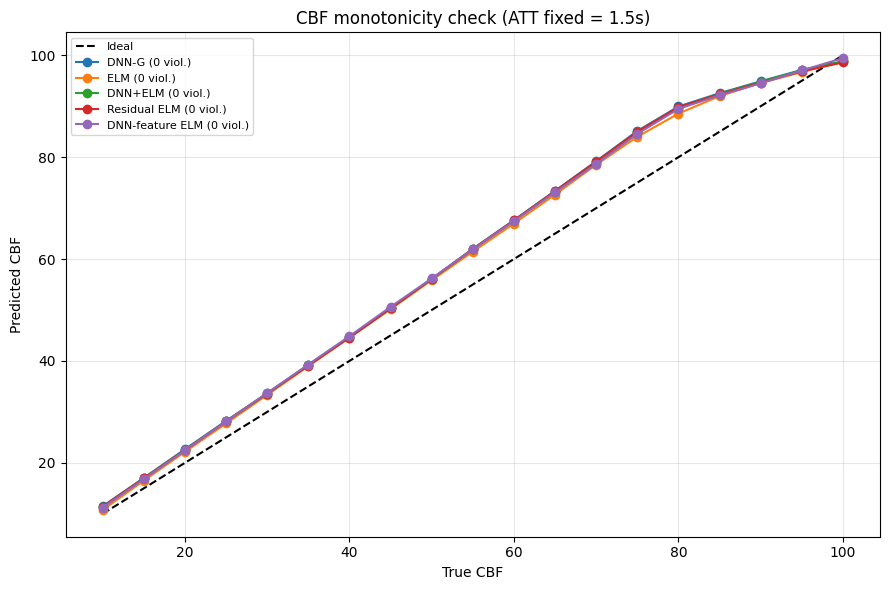

CBF monotonicity violations by model:
  DNN-G             : 0 violations  (STRICTLY MONOTONIC)
  ELM               : 0 violations  (STRICTLY MONOTONIC)
  DNN+ELM           : 0 violations  (STRICTLY MONOTONIC)
  Residual ELM      : 0 violations  (STRICTLY MONOTONIC)
  DNN-feature ELM   : 0 violations  (STRICTLY MONOTONIC)


In [18]:
ATT_FIXED = 1.5
CBF_SWEEP = np.arange(10.0, 100.1, 5.0)

sig_sweep = compute_signals_vec(CBF_SWEEP, np.full_like(CBF_SWEEP, ATT_FIXED)) * SCALE
clean_sweep_phys = 2.0 * sig_sweep
clean_sweep_norm = (clean_sweep_phys - X_mean) / X_std

mono_preds = predict_all_models(clean_sweep_norm)

monotonicity_violations = {}
plt.figure(figsize=(9, 6))
plt.plot(CBF_SWEEP, CBF_SWEEP, "--", color="black", label="Ideal")
for name in MODEL_NAMES:
    pred = mono_preds[name]["CBF"]
    diffs = np.diff(pred)
    n_violations = int(np.sum(diffs < 0))
    monotonicity_violations[name] = n_violations
    plt.plot(CBF_SWEEP, pred, "o-", label=f"{name} ({n_violations} viol.)")

plt.xlabel("True CBF"); plt.ylabel("Predicted CBF")
plt.title(f"CBF monotonicity check (ATT fixed = {ATT_FIXED}s)")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "cbf_monotonicity.png"), dpi=120)
plt.show()

print("CBF monotonicity violations by model:")
for name, v in monotonicity_violations.items():
    print(f"  {name:18s}: {v} violations  {'(STRICTLY MONOTONIC)' if v == 0 else ''}")

### 16b. ATT response (CBF fixed at 50)

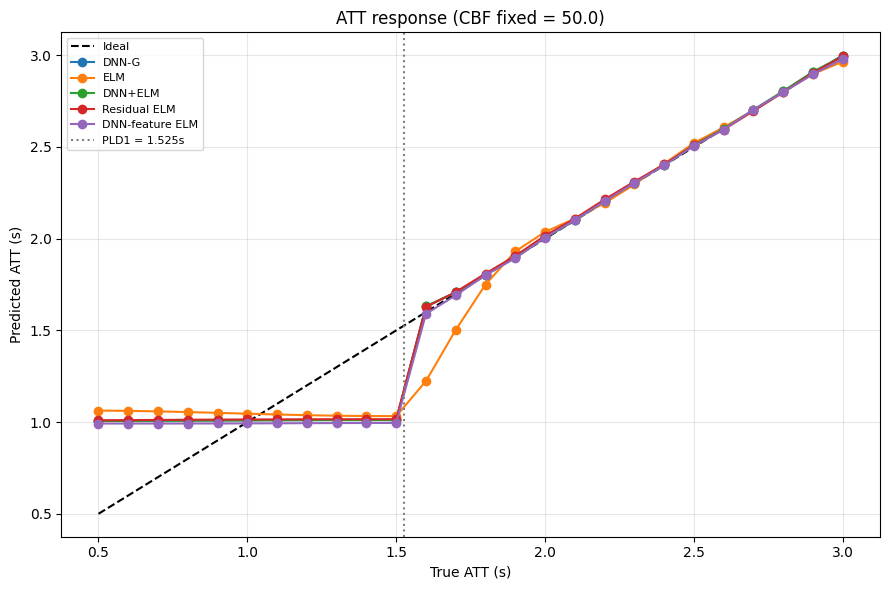

ATT response sweep — RMSE/MAE/CCC by model:


,Model,RMSE,MAE,CCC
0,DNN-G,0.2048,0.1189,0.9611
1,ELM,0.2310,0.1516,0.9499
2,DNN+ELM,0.2048,0.1189,0.9611
3,Residual ELM,0.2048,0.1206,0.9610
4,DNN-feature ELM,0.2050,0.1183,0.9613


In [19]:
CBF_FIXED = 50.0
ATT_SWEEP = np.linspace(0.5, 3.0, 26)

sig_att_sweep = compute_signals_vec(np.full_like(ATT_SWEEP, CBF_FIXED), ATT_SWEEP) * SCALE
clean_att_sweep_phys = 2.0 * sig_att_sweep
clean_att_sweep_norm = (clean_att_sweep_phys - X_mean) / X_std

att_sweep_preds = predict_all_models(clean_att_sweep_norm)

plt.figure(figsize=(9, 6))
plt.plot(ATT_SWEEP, ATT_SWEEP, "--", color="black", label="Ideal")
att_response_rows = []
for name in MODEL_NAMES:
    pred = att_sweep_preds[name]["ATT"]
    plt.plot(ATT_SWEEP, pred, "o-", label=name)
    m = calc_metrics(ATT_SWEEP, pred)
    m["Model"] = name
    att_response_rows.append(m)

plt.axvline(1.525, linestyle=":", color="gray", label="PLD1 = 1.525s")
plt.xlabel("True ATT (s)"); plt.ylabel("Predicted ATT (s)")
plt.title(f"ATT response (CBF fixed = {CBF_FIXED})")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "att_response.png"), dpi=120)
plt.show()

att_response_df = pd.DataFrame(att_response_rows)[["Model", "RMSE", "MAE", "CCC"]]
print("ATT response sweep — RMSE/MAE/CCC by model:")
display(att_response_df.round(4))

### 16c. Error by CBF range (clean population)

In [20]:
CBF_RANGE_BINS = [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100)]

cbf_range_rows = []
for lo, hi in CBF_RANGE_BINS:
    mask = (clean_cbf_true >= lo) & (clean_cbf_true < hi if hi < 100 else clean_cbf_true <= hi)
    for name in MODEL_NAMES:
        pred = clean_preds[name]["CBF"][mask]
        true = clean_cbf_true[mask]
        m = calc_metrics(true, pred)
        cbf_range_rows.append({"Range": f"{lo}-{hi}", "Model": name, "N": int(mask.sum()),
                                "RMSE": m["RMSE"], "MAE": m["MAE"], "Bias": m["Bias"], "CCC": m["CCC"]})

cbf_range_df = pd.DataFrame(cbf_range_rows)
print("Error by CBF range:")
display(cbf_range_df.pivot(index="Range", columns="Model", values="RMSE").round(4))
cbf_range_df.to_csv(os.path.join(OUTPUT_DIR, "cbf_range_results.csv"), index=False)

Error by CBF range:


Model,DNN+ELM,DNN-G,DNN-feature ELM,ELM,Residual ELM
Range,,,,,
0-20,0.9433,0.8836,0.7250,1.4855,0.7045
20-40,1.4972,1.4747,1.4137,1.7040,1.4135
40-60,2.3934,2.3901,2.3352,2.4526,2.3841
60-80,3.3906,3.4039,3.2723,3.4162,3.3750
80-100,3.3783,3.3408,3.4210,3.6012,3.3587


### 16d. Error by ATT range (clean population)

In [21]:
ATT_RANGE_BINS = [(0.5, 1.0), (1.0, 1.4), (1.4, 1.525), (1.525, 1.8), (1.8, 2.2), (2.2, 2.6), (2.6, 3.0)]

att_range_rows = []
for lo, hi in ATT_RANGE_BINS:
    mask = (clean_att_true >= lo) & (clean_att_true < hi if hi < 3.0 else clean_att_true <= hi)
    for name in MODEL_NAMES:
        pred = clean_preds[name]["ATT"][mask]
        true = clean_att_true[mask]
        if mask.sum() == 0:
            continue
        m = calc_metrics(true, pred)
        att_range_rows.append({"Range": f"{lo}-{hi}", "Model": name, "N": int(mask.sum()),
                                "RMSE": m["RMSE"], "MAE": m["MAE"], "Bias": m["Bias"], "CCC": m["CCC"]})

att_range_df = pd.DataFrame(att_range_rows)
print("Error by ATT range:")
display(att_range_df.pivot(index="Range", columns="Model", values="RMSE").round(4))
att_range_df.to_csv(os.path.join(OUTPUT_DIR, "att_range_results.csv"), index=False)

Error by ATT range:


Model,DNN+ELM,DNN-G,DNN-feature ELM,ELM,Residual ELM
Range,,,,,
0.5-1.0,0.3066,0.3066,0.2992,0.3453,0.3077
1.0-1.4,0.2189,0.2189,0.2261,0.1873,0.2176
1.4-1.525,0.4131,0.4131,0.4212,0.3747,0.4121
1.525-1.8,0.1875,0.1875,0.1894,0.2934,0.1868
1.8-2.2,0.0066,0.0066,0.0069,0.0742,0.0115
2.2-2.6,0.0094,0.0094,0.0069,0.0423,0.0095
2.6-3.0,0.0113,0.0113,0.0117,0.0590,0.0119


### 16e. Required plots

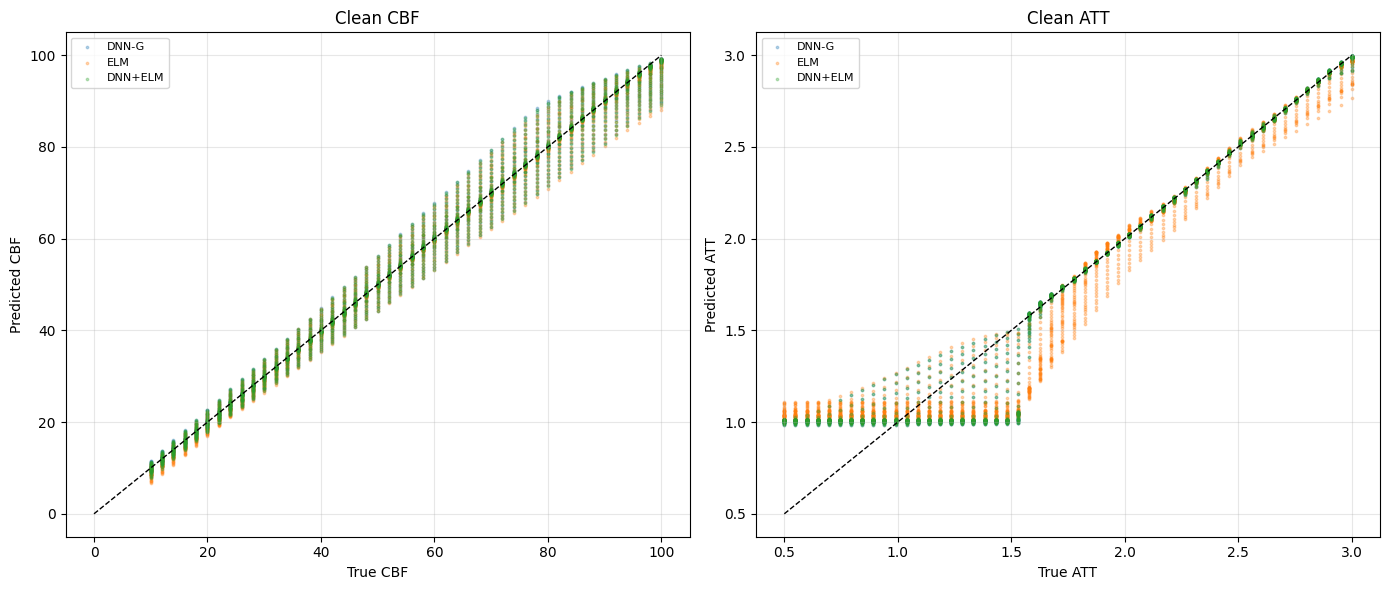

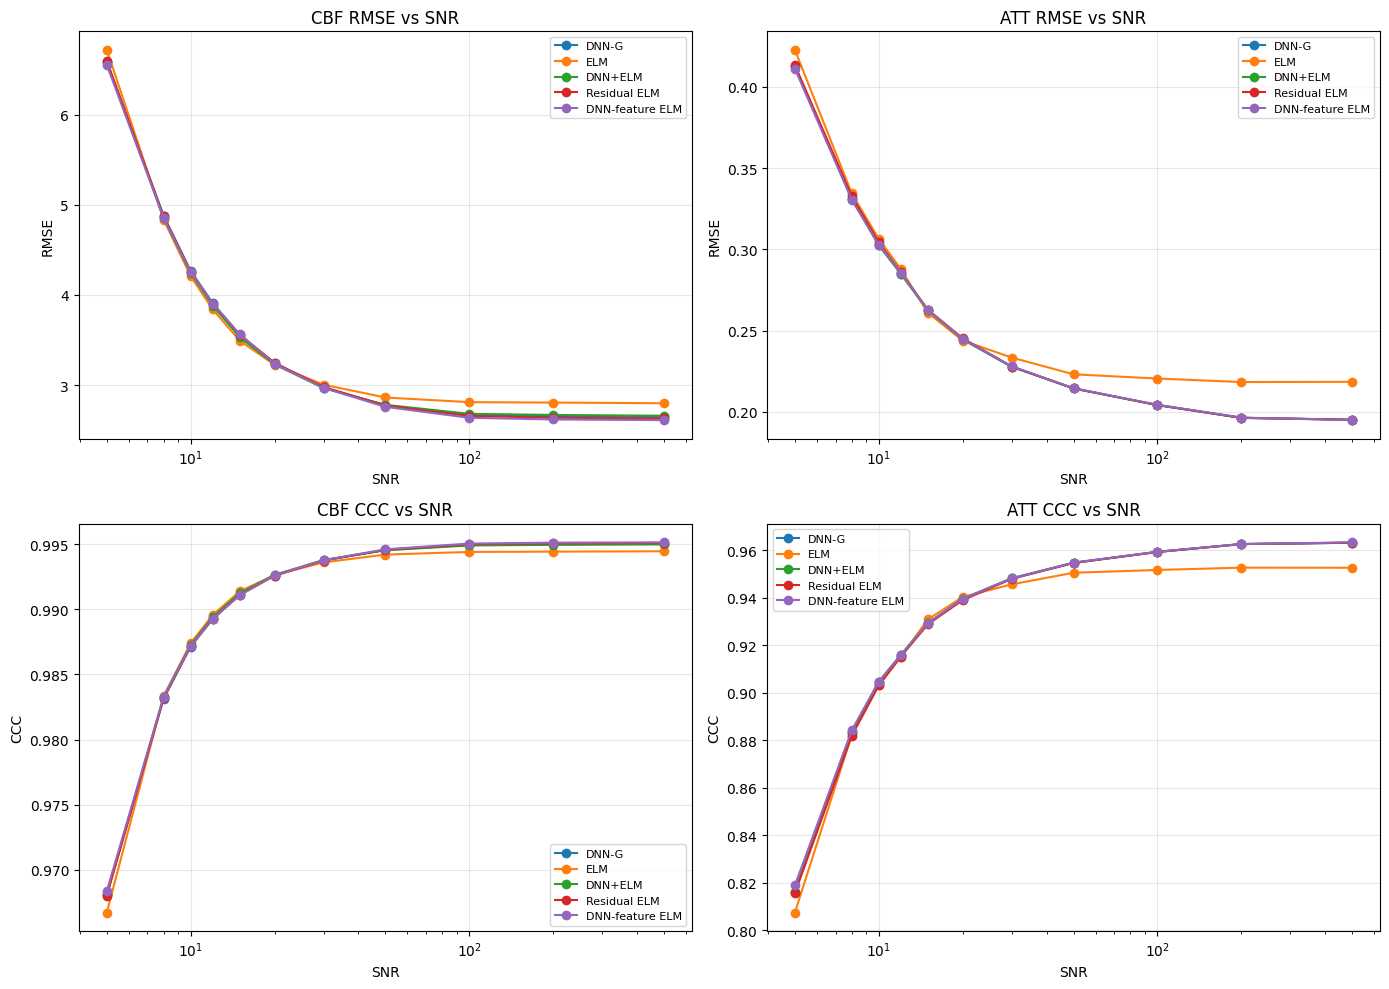

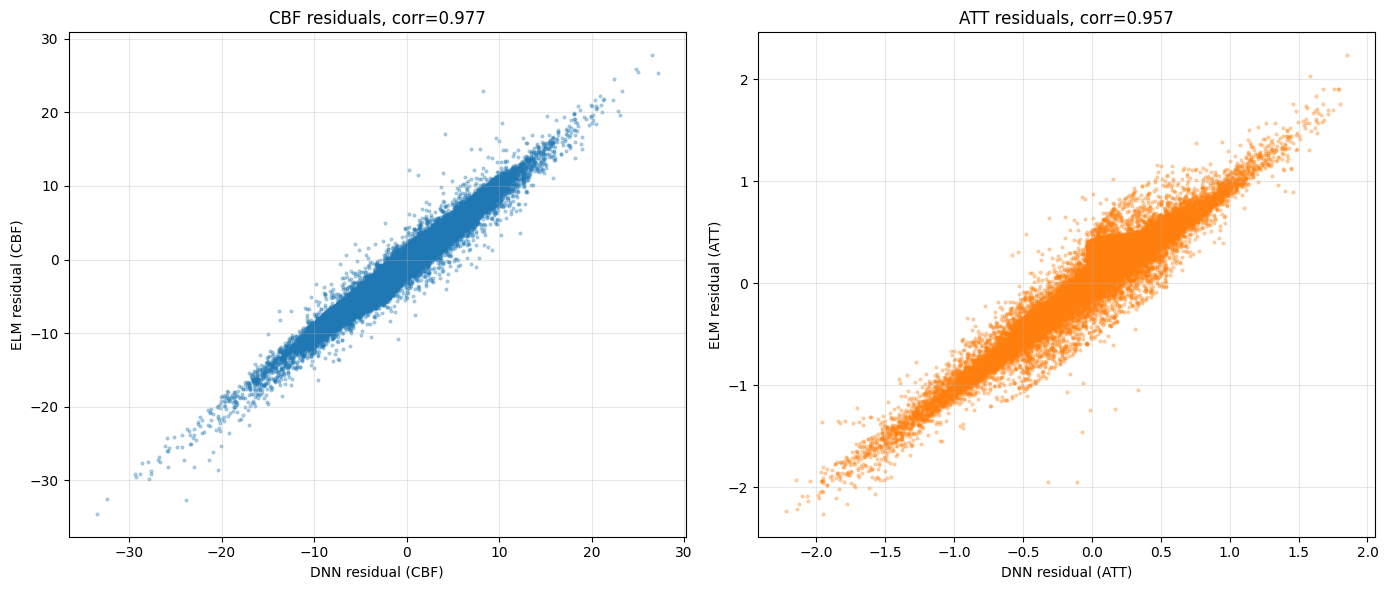

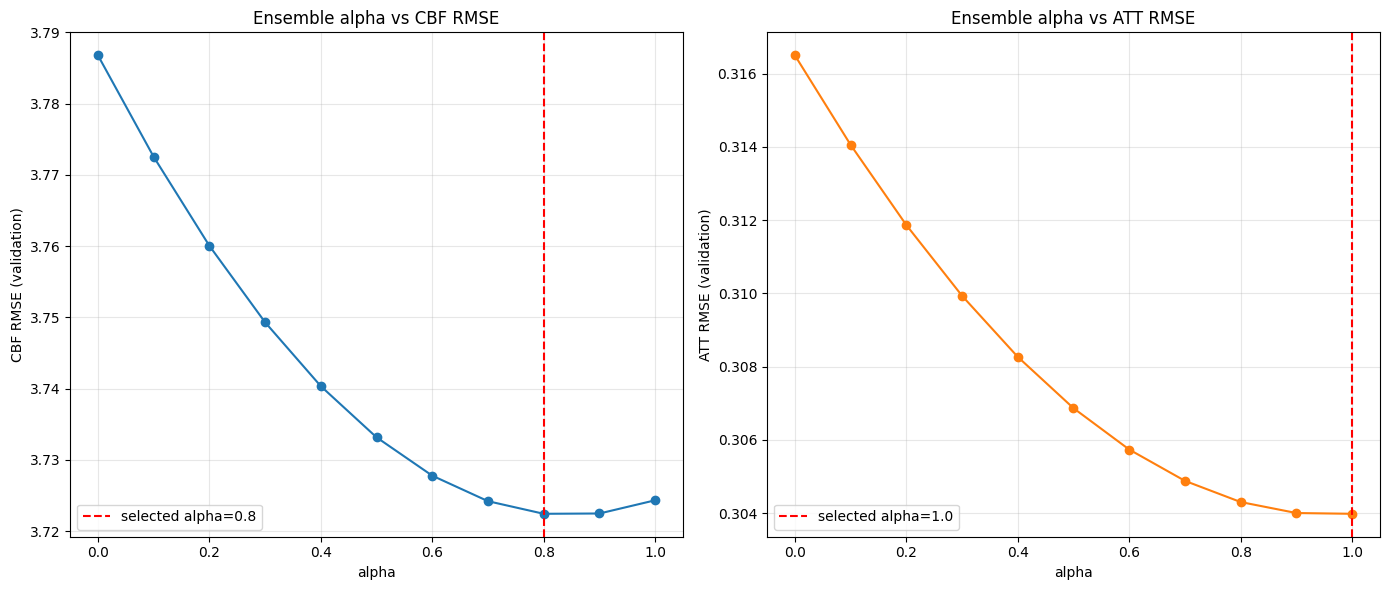

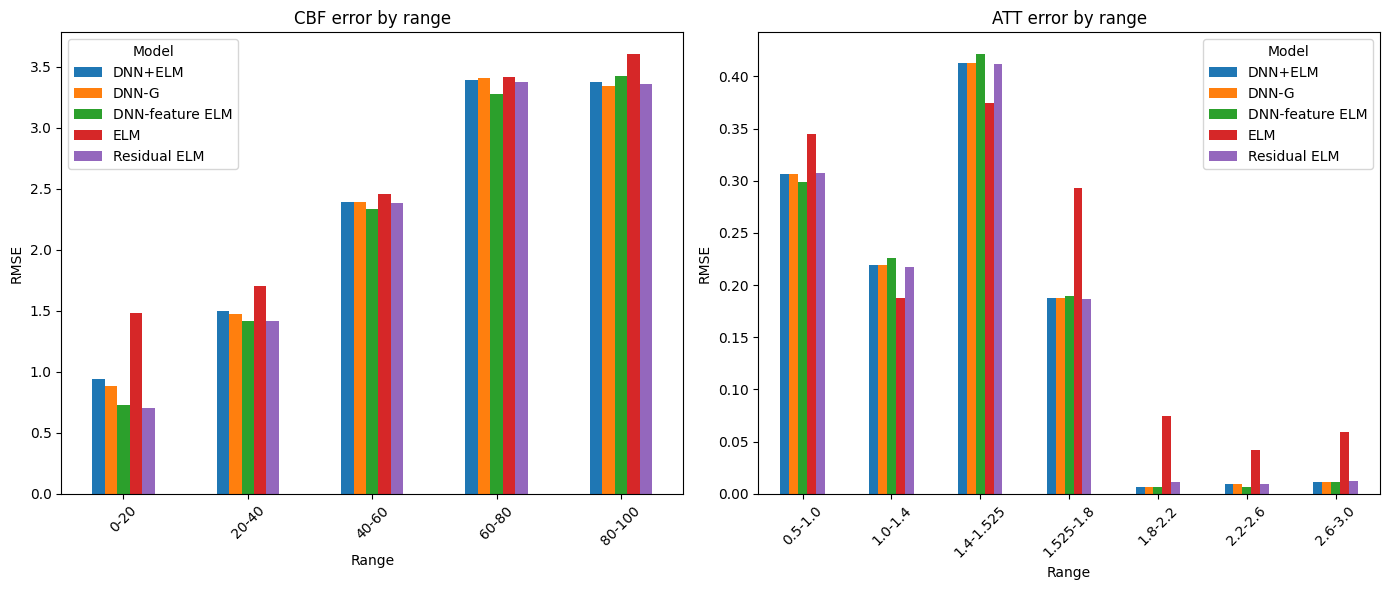

In [22]:
# 1 & 2. Clean CBF / ATT: True vs DNN vs ELM vs Hybrid
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, color in zip(["DNN-G", "ELM", "DNN+ELM"], ["tab:blue", "tab:orange", "tab:green"]):
    axes[0].scatter(clean_cbf_true, clean_preds[name]["CBF"], s=3, alpha=0.3, label=name, color=color)
    axes[1].scatter(clean_att_true, clean_preds[name]["ATT"], s=3, alpha=0.3, label=name, color=color)
axes[0].plot([0, 100], [0, 100], "k--", lw=1)
axes[1].plot([0.5, 3.0], [0.5, 3.0], "k--", lw=1)
axes[0].set_xlabel("True CBF"); axes[0].set_ylabel("Predicted CBF"); axes[0].set_title("Clean CBF")
axes[1].set_xlabel("True ATT"); axes[1].set_ylabel("Predicted ATT"); axes[1].set_title("Clean ATT")
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR, "clean_scatter.png"), dpi=120); plt.show()

# 5, 6, 7, 8. RMSE / CCC vs SNR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
finite_snr = snr_results_df[np.isfinite(snr_results_df["SNR"])]
for name in MODEL_NAMES:
    sub = finite_snr[finite_snr["Model"] == name].sort_values("SNR")
    axes[0, 0].plot(sub["SNR"], sub["CBF_RMSE"], "o-", label=name)
    axes[0, 1].plot(sub["SNR"], sub["ATT_RMSE"], "o-", label=name)
    axes[1, 0].plot(sub["SNR"], sub["CBF_CCC"], "o-", label=name)
    axes[1, 1].plot(sub["SNR"], sub["ATT_CCC"], "o-", label=name)
for ax, title, ylab in zip(axes.flat,
                            ["CBF RMSE vs SNR", "ATT RMSE vs SNR", "CBF CCC vs SNR", "ATT CCC vs SNR"],
                            ["RMSE", "RMSE", "CCC", "CCC"]):
    ax.set_xscale("log"); ax.set_xlabel("SNR"); ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR, "snr_curves.png"), dpi=120); plt.show()

# 9. DNN residual vs ELM residual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(err_dnn_cbf, err_elm_cbf, s=4, alpha=0.3)
axes[0].set_xlabel("DNN residual (CBF)"); axes[0].set_ylabel("ELM residual (CBF)")
axes[0].set_title(f"CBF residuals, corr={corr_cbf:.3f}"); axes[0].grid(alpha=0.3)
axes[1].scatter(err_dnn_att, err_elm_att, s=4, alpha=0.3, color="tab:orange")
axes[1].set_xlabel("DNN residual (ATT)"); axes[1].set_ylabel("ELM residual (ATT)")
axes[1].set_title(f"ATT residuals, corr={corr_att:.3f}"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR, "residual_correlation.png"), dpi=120); plt.show()

# 10 & 11. Ensemble alpha vs RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(alpha_sweep_cbf["alpha"], alpha_sweep_cbf["RMSE"], "o-")
axes[0].axvline(alpha_CBF, color="red", linestyle="--", label=f"selected alpha={alpha_CBF}")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("CBF RMSE (validation)"); axes[0].set_title("Ensemble alpha vs CBF RMSE")
axes[1].plot(alpha_sweep_att["alpha"], alpha_sweep_att["RMSE"], "o-", color="tab:orange")
axes[1].axvline(alpha_ATT, color="red", linestyle="--", label=f"selected alpha={alpha_ATT}")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("ATT RMSE (validation)"); axes[1].set_title("Ensemble alpha vs ATT RMSE")
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR, "ensemble_alpha_sweep.png"), dpi=120); plt.show()

# 12 & 13. Error by CBF range / ATT range
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cbf_pivot = cbf_range_df.pivot(index="Range", columns="Model", values="RMSE")
cbf_pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("CBF error by range"); axes[0].set_ylabel("RMSE"); axes[0].tick_params(axis="x", rotation=45)
att_pivot = att_range_df.pivot(index="Range", columns="Model", values="RMSE")
att_pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("ATT error by range"); axes[1].set_ylabel("RMSE"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR, "error_by_range.png"), dpi=120); plt.show()

### 16f. DNN vs ELM vs Bayesian vs NLS — final comparison table

Uses the clean-population subsample for NLS/Bayesian (Section 14) matched
against the same models evaluated on that identical subsample, so all rows
are comparable on the same test population. Where a metric is unavailable for
a given method it is reported as `N/A` rather than invented.

In [23]:
import pickle

# Models
torch.save(CBFnet_G.state_dict(), os.path.join(OUTPUT_DIR, "CBF_G_best.pth"))
torch.save(ATTnet_G.state_dict(), os.path.join(OUTPUT_DIR, "ATT_G_best.pth"))

with open(os.path.join(OUTPUT_DIR, "ELM_CBF.pkl"), "wb") as f:
    pickle.dump(ELM_CBF, f)
with open(os.path.join(OUTPUT_DIR, "ELM_ATT.pkl"), "wb") as f:
    pickle.dump(ELM_ATT, f)
with open(os.path.join(OUTPUT_DIR, "ELM_RESID_CBF.pkl"), "wb") as f:
    pickle.dump(ELM_RESID_CBF, f)
with open(os.path.join(OUTPUT_DIR, "ELM_RESID_ATT.pkl"), "wb") as f:
    pickle.dump(ELM_RESID_ATT, f)
with open(os.path.join(OUTPUT_DIR, "ELM_FEAT_CBF.pkl"), "wb") as f:
    pickle.dump(ELM_FEAT_CBF, f)
with open(os.path.join(OUTPUT_DIR, "ELM_FEAT_ATT.pkl"), "wb") as f:
    pickle.dump(ELM_FEAT_ATT, f)

# Results tables (clean_results, snr_results, error_correlation, cbf/att range were already saved)
alpha_sweep_cbf.assign(target="CBF").to_csv(os.path.join(OUTPUT_DIR, "ensemble_results_cbf.csv"), index=False)
alpha_sweep_att.assign(target="ATT").to_csv(os.path.join(OUTPUT_DIR, "ensemble_results_att.csv"), index=False)
pd.concat([alpha_sweep_cbf.assign(target="CBF"), alpha_sweep_att.assign(target="ATT")]).to_csv(os.path.join(OUTPUT_DIR, "ensemble_results.csv"), index=False)

experiment_config = {
    "random_seed": SEED,
    "quick_test_mode": QUICK_TEST,
    "training_samples": {"N_train": N_TRAIN, "N_val": N_VAL, "N_test": N_TEST},
    "cbf_range": [CBF_MIN, CBF_MAX],
    "att_range": [ATT_MIN, ATT_MAX],
    "snr_values": [float(v) if np.isfinite(v) else None for v in SNR_VALUES],
    "dnn_architecture": {
        "CBFnet_G": {"n_hidden_layers": 5, "n_neurons": 128, "params": n_params_cbf},
        "ATTnet_G": {"n_hidden_layers": 4, "n_neurons": 64, "params": n_params_att},
    },
    "normalization": {
        "X_mean": X_mean.squeeze().tolist(),
        "X_std": X_std.squeeze().tolist()
    },
    "target_standardization": {
        "CBF_mean": CBF_mean,
        "CBF_std": CBF_std,
        "ATT_mean": ATT_mean,
        "ATT_std": ATT_std,
    },
    "elm": {
        "hidden_size_cbf": ELM_CBF.hidden_neurons,
        "hidden_size_att": ELM_ATT.hidden_neurons,
        "activation": ELM_CBF.activation_name,
        "regularization": ELM_CBF.reg,
        "seed_cbf": best_cbf_seed,
        "seed_att": best_att_seed,
    },
    "ensemble_alpha": {"alpha_CBF": alpha_CBF, "alpha_ATT": alpha_ATT},
    "monotonicity_violations": monotonicity_violations,
}

with open(os.path.join(OUTPUT_DIR, "experiment_config.json"), "w") as f:
    json.dump(experiment_config, f, indent=2)

print(f"All models, tables, plots, and experiment_config.json saved to: {OUTPUT_DIR}")
print("\nFiles written:")
for root, _, files in os.walk(OUTPUT_DIR):
    for fn in sorted(files):
        print("  ", os.path.join(root, fn).replace(OUTPUT_DIR, "").lstrip("/"))

All models, tables, plots, and experiment_config.json saved to: /kaggle/working/experiment_H_DNN_ELM

Files written:
   ATT_G_best.pth
   ATT_I_robust_best.pth
   ATT_y_mean_std.npy
   CBF_G_best.pth
   CBF_I_robust_best.pth
   CBF_y_mean_std.npy
   ELM_ATT.pkl
   ELM_CBF.pkl
   ELM_FEAT_ATT.pkl
   ELM_FEAT_CBF.pkl
   ELM_RESID_ATT.pkl
   ELM_RESID_CBF.pkl
   X_mean.npy
   X_std.npy
   att_range_results.csv
   cbf_range_results.csv
   clean_results.csv
   ensemble_results.csv
   ensemble_results_att.csv
   ensemble_results_cbf.csv
   error_correlation.csv
   experiment_config.json
   snr_results.csv
   plots/att_response.png
   plots/cbf_monotonicity.png
   plots/clean_scatter.png
   plots/ensemble_alpha_sweep.png
   plots/error_by_range.png
   plots/residual_correlation.png
   plots/snr_curves.png


## SECTION 17 — Save models, results, and configuration

In [24]:
print("============================================================")
print("DNN FINAL CLEAN PERFORMANCE")
print("============================================================")
clean_cbf_dnn = clean_results_df[clean_results_df["Model"] == "DNN-G"].iloc[0]
print(f"CBF:\nRMSE: {clean_cbf_dnn['CBF_RMSE']:.4f}\nMAE:  {clean_cbf_dnn['CBF_MAE']:.4f}\nR²:   {clean_cbf_dnn['CBF_R2']:.4f}\nCCC:  {clean_cbf_dnn['CBF_CCC']:.4f}\n")

print(f"ATT:\nRMSE: {clean_cbf_dnn['ATT_RMSE']:.4f}\nMAE:  {clean_cbf_dnn['ATT_MAE']:.4f}\nR²:   {clean_cbf_dnn['ATT_R2']:.4f}\nCCC:  {clean_cbf_dnn['ATT_CCC']:.4f}\n")

print("============================================================")
print("DNN SNR PERFORMANCE")
print("============================================================")
dnn_snr = snr_results_df[snr_results_df["Model"] == "DNN-G"].sort_values("SNR")
print(f"{'SNR':<6} | {'CBF RMSE':<10} | {'CBF MAE':<10} | {'CBF CCC':<10} | {'ATT RMSE':<10} | {'ATT MAE':<10} | {'ATT CCC':<10}")
print("-" * 85)
for _, row in dnn_snr.iterrows():
    print(f"{row['SNR']:<6} | {row['CBF_RMSE']:<10.4f} | {row['CBF_MAE']:<10.4f} | {row['CBF_CCC']:<10.4f} | {row['ATT_RMSE']:<10.4f} | {row['ATT_MAE']:<10.4f} | {row['ATT_CCC']:<10.4f}")

print("\n============================================================")
print("FINAL ELM COMPARISON (TEST SET)")
print("============================================================")
final_models = ["DNN-G", "ELM", "DNN+ELM", "Residual ELM"]
print(f"{'Model':<18} {'CBF RMSE':<10} {'CBF MAE':<10} {'CBF CCC':<10}")
print("-" * 52)
# Re-calculate test metrics for the summary
test_preds = {
    "DNN-G": (CBF_DNN_test, ATT_DNN_test),
    "ELM": (CBF_ELM_test, ATT_ELM_test),
    "DNN+ELM": (CBF_ENS_test, ATT_ENS_test),
    "Residual ELM": (CBF_RESID_test, ATT_RESID_test)
}

for name in final_models:
    cbf_pred, _ = test_preds[name]
    m = calc_metrics(Y_test[:, 0], cbf_pred)
    print(f"{name:<18} {m['RMSE']:<10.4f} {m['MAE']:<10.4f} {m['CCC']:<10.4f}")

print(f"\n{'Model':<18} {'ATT RMSE':<10} {'ATT MAE':<10} {'ATT CCC':<10}")
print("-" * 52)
for name in final_models:
    _, att_pred = test_preds[name]
    m = calc_metrics(Y_test[:, 1], att_pred)
    print(f"{name:<18} {m['RMSE']:<10.4f} {m['MAE']:<10.4f} {m['CCC']:<10.4f}")

print("\n============================================================")
print("EXTERNAL COMPARISON TEMPLATE (For Classmate Results)")
print("============================================================")
print(f"{'Model':<18} {'CBF RMSE':<10} {'CBF MAE':<10} {'CBF CCC':<10} {'ATT RMSE':<10} {'ATT MAE':<10} {'ATT CCC':<10}")
for name in final_models:
    cbf_pred, att_pred = test_preds[name]
    mc = calc_metrics(Y_test[:, 0], cbf_pred)
    ma = calc_metrics(Y_test[:, 1], att_pred)
    print(f"{name:<18} {mc['RMSE']:<10.4f} {mc['MAE']:<10.4f} {mc['CCC']:<10.4f} {ma['RMSE']:<10.4f} {ma['MAE']:<10.4f} {ma['CCC']:<10.4f}")
print(f"{'Bayesian':<18} EXTERNAL RESULT — CLASSMATE IMPLEMENTATION")
print(f"{'NLS':<18} EXTERNAL RESULT — CLASSMATE IMPLEMENTATION")

DNN FINAL CLEAN PERFORMANCE
CBF:
RMSE: 2.6433
MAE:  1.5759
R²:   0.9901
CCC:  0.9950

ATT:
RMSE: 0.1947
MAE:  0.1134
R²:   0.9299
CCC:  0.9634

DNN SNR PERFORMANCE
SNR    | CBF RMSE   | CBF MAE    | CBF CCC    | ATT RMSE   | ATT MAE    | ATT CCC   
-------------------------------------------------------------------------------------
5.0    | 6.5882     | 5.1220     | 0.9681     | 0.4130     | 0.2896     | 0.8162    
8.0    | 4.8802     | 3.7858     | 0.9831     | 0.3312     | 0.2304     | 0.8834    
10.0   | 4.2676     | 3.2983     | 0.9871     | 0.3026     | 0.2105     | 0.9046    
12.0   | 3.9099     | 2.9985     | 0.9892     | 0.2851     | 0.1944     | 0.9159    
15.0   | 3.5560     | 2.7040     | 0.9911     | 0.2625     | 0.1802     | 0.9293    
20.0   | 3.2437     | 2.4095     | 0.9926     | 0.2446     | 0.1660     | 0.9396    
30.0   | 2.9705     | 2.0887     | 0.9938     | 0.2277     | 0.1511     | 0.9482    
50.0   | 2.7745     | 1.8261     | 0.9945     | 0.2144     | 0.1363   

In [25]:
print("\n============================================================")
print("DNN vs ELM: SNR 10, 15, 20 COMPARISON")
print("============================================================")

target_snrs = [10.0, 15.0, 20.0]
models_to_compare = ["DNN-G", "ELM", "DNN+ELM", "Residual ELM"]

for snr in target_snrs:
    print(f"\n--- SNR = {snr} ---")
    print(f"{'Model':<18} | {'CBF RMSE':<9} | {'CBF MAE':<9} | {'CBF CCC':<9} | {'ATT RMSE':<9} | {'ATT MAE':<9} | {'ATT CCC':<9}")
    print("-" * 90)
    
    snr_slice = snr_results_df[snr_results_df["SNR"] == snr]
    for _, row in snr_slice.iterrows():
        if row["Model"] in models_to_compare:
            print(f"{row['Model']:<18} | {row['CBF_RMSE']:<9.4f} | {row['CBF_MAE']:<9.4f} | {row['CBF_CCC']:<9.4f} | {row['ATT_RMSE']:<9.4f} | {row['ATT_MAE']:<9.4f} | {row['ATT_CCC']:<9.4f}")


DNN vs ELM: SNR 10, 15, 20 COMPARISON

--- SNR = 10.0 ---
Model              | CBF RMSE  | CBF MAE   | CBF CCC   | ATT RMSE  | ATT MAE   | ATT CCC  
------------------------------------------------------------------------------------------
DNN-G              | 4.2676    | 3.2983    | 0.9871    | 0.3026    | 0.2105    | 0.9046   
ELM                | 4.2091    | 3.2657    | 0.9874    | 0.3065    | 0.2144    | 0.9032   
DNN+ELM            | 4.2420    | 3.2798    | 0.9873    | 0.3026    | 0.2105    | 0.9046   
Residual ELM       | 4.2580    | 3.2825    | 0.9872    | 0.3044    | 0.2115    | 0.9032   

--- SNR = 15.0 ---
Model              | CBF RMSE  | CBF MAE   | CBF CCC   | ATT RMSE  | ATT MAE   | ATT CCC  
------------------------------------------------------------------------------------------
DNN-G              | 3.5560    | 2.7040    | 0.9911    | 0.2625    | 0.1802    | 0.9293   
ELM                | 3.4927    | 2.6698    | 0.9914    | 0.2610    | 0.1812    | 0.9309   
DNN+ELM    

In [26]:
# ============================================================
# DEFINITIVE SNR=INFINITY vs CLEAN POPULATION CHECK
# ============================================================

print("=" * 75)
print("SNR = INFINITY vs CLEAN INPUT CONSISTENCY CHECK")
print("=" * 75)

# ------------------------------------------------------------
# 1. Direct clean training-distribution input
# ------------------------------------------------------------

X_clean_direct = clean_input_phys.astype(np.float32)

# ------------------------------------------------------------
# 2. SNR = infinity generated input
# ------------------------------------------------------------

sig = clean_sig.astype(np.float32)

e1 = np.zeros_like(sig)
e2 = np.zeros_like(sig)
e3 = np.zeros_like(sig)
e4 = np.zeros_like(sig)

mc = np.sqrt(
    (sig + e1)**2 + e2**2
)

ml = np.sqrt(
    (sig + e3)**2 + e4**2
)

X_clean_snr_inf = (
    mc + ml
).astype(np.float32)

# ------------------------------------------------------------
# 3. Compare
# ------------------------------------------------------------

print("\nDirect clean input:")
print("shape:", X_clean_direct.shape)
print("min  :", X_clean_direct.min())
print("max  :", X_clean_direct.max())
print("mean :", X_clean_direct.mean())

print("\nSNR=inf generated input:")
print("shape:", X_clean_snr_inf.shape)
print("min  :", X_clean_snr_inf.min())
print("max  :", X_clean_snr_inf.max())
print("mean :", X_clean_snr_inf.mean())

difference = X_clean_snr_inf - X_clean_direct

print("\nDifference:")
print("max abs difference :", np.max(np.abs(difference)))
print("mean abs difference:", np.mean(np.abs(difference)))

assert np.allclose(
    X_clean_snr_inf,
    X_clean_direct,
    atol=1e-5
), "SNR=inf does NOT reproduce the direct clean input!"

print("\n✓ SNR=inf exactly reproduces the clean input.")

SNR = INFINITY vs CLEAN INPUT CONSISTENCY CHECK

Direct clean input:
shape: (2392, 4)
min  : 24.515093
max  : 1944.6622
mean : 528.94684

SNR=inf generated input:
shape: (2392, 4)
min  : 24.515093
max  : 1944.6622
mean : 528.94684

Difference:
max abs difference : 0.0
mean abs difference: 0.0

✓ SNR=inf exactly reproduces the clean input.


In [27]:
# ============================================================
# DNN CLEAN vs SNR=INFINITY PREDICTION CHECK
# ============================================================

X_direct_norm = (
    X_clean_direct - X_mean
) / X_std

X_inf_norm = (
    X_clean_snr_inf - X_mean
) / X_std

pred_direct = predict_all_models(X_direct_norm)
pred_inf = predict_all_models(X_inf_norm)

for name in MODEL_NAMES:

    print("\n" + "=" * 60)
    print(name)

    cbf_diff = (
        pred_inf[name]["CBF"]
        - pred_direct[name]["CBF"]
    )

    att_diff = (
        pred_inf[name]["ATT"]
        - pred_direct[name]["ATT"]
    )

    print(
        "CBF max prediction difference:",
        np.max(np.abs(cbf_diff))
    )

    print(
        "ATT max prediction difference:",
        np.max(np.abs(att_diff))
    )

    m_direct_cbf = calc_metrics(
        clean_cbf_true,
        pred_direct[name]["CBF"]
    )

    m_inf_cbf = calc_metrics(
        clean_cbf_true,
        pred_inf[name]["CBF"]
    )

    m_direct_att = calc_metrics(
        clean_att_true,
        pred_direct[name]["ATT"]
    )

    m_inf_att = calc_metrics(
        clean_att_true,
        pred_inf[name]["ATT"]
    )

    print("\nCBF")
    print(
        "Direct clean RMSE:",
        m_direct_cbf["RMSE"]
    )
    print(
        "SNR=inf RMSE     :",
        m_inf_cbf["RMSE"]
    )

    print("\nATT")
    print(
        "Direct clean RMSE:",
        m_direct_att["RMSE"]
    )
    print(
        "SNR=inf RMSE     :",
        m_inf_att["RMSE"]
    )


DNN-G
CBF max prediction difference: 0.0
ATT max prediction difference: 0.0

CBF
Direct clean RMSE: 2.643346144790572
SNR=inf RMSE     : 2.643346144790572

ATT
Direct clean RMSE: 0.19472615329071047
SNR=inf RMSE     : 0.19472615329071047

ELM
CBF max prediction difference: 0.0
ATT max prediction difference: 0.0

CBF
Direct clean RMSE: 2.795887798685681
SNR=inf RMSE     : 2.795887798685681

ATT
Direct clean RMSE: 0.21835066788125052
SNR=inf RMSE     : 0.21835066788125052

DNN+ELM
CBF max prediction difference: 0.0
ATT max prediction difference: 0.0

CBF
Direct clean RMSE: 2.656626043294555
SNR=inf RMSE     : 2.656626043294555

ATT
Direct clean RMSE: 0.19472615329071047
SNR=inf RMSE     : 0.19472615329071047

Residual ELM
CBF max prediction difference: 0.0
ATT max prediction difference: 0.0

CBF
Direct clean RMSE: 2.626377383531802
SNR=inf RMSE     : 2.626377383531802

ATT
Direct clean RMSE: 0.19475049173855702
SNR=inf RMSE     : 0.19475049173855702

DNN-feature ELM
CBF max prediction d